# Separating Driver Skill from Car Performance in Formula 1

This notebook implements three Bayesian probabilistic graphical models to decompose
Formula 1 race finishing orders (2011–2024) into latent driver skill and constructor
performance.
**Models:**
1. Static skills (one $s_d$, one $c_k$ across all seasons)
2. Temporal dynamics (AR(1) random walk per season)
3. Wet-weather physics (multiplicative rain rescaling)

**Inference:** SVI (all models) + NUTS validation (Model 1).
Results cached to `outputs/pgm_model/final_report/`.

In [1]:
import os, types, time
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, MCMC, NUTS, Trace_ELBO
from dataclasses import dataclass
from IPython.display import Image, display
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

OUTPUT_DIR = 'outputs/pgm_model'
PLOTS_DIR  = os.path.join(OUTPUT_DIR, 'plots')
REPORT_DIR = os.path.join(PLOTS_DIR, 'report')
os.makedirs(PLOTS_DIR, exist_ok=True)


torch.manual_seed(42)
pyro.set_rng_seed(42)

def show(path):
    if os.path.exists(path):
        display(Image(path))
    else:
        print(f'[Figure not found: {path}]')

print(f'Pyro {pyro.__version__}  |  PyTorch {torch.__version__}')

_drivers = pd.read_csv('data_preprocessing/drivers.csv', na_values=['\\N'])
_drivers['name'] = _drivers['forename'] + ' ' + _drivers['surname']
DRIVER_NAMES = _drivers.set_index('driverId')['name'].to_dict()

_cons = pd.read_csv('data_preprocessing/constructors.csv', na_values=['\\N'])
CONSTRUCTOR_NAMES = _cons.set_index('constructorId')['name'].to_dict()


Pyro 1.9.1  |  PyTorch 2.11.0


/Users/christianrand/Projects/MBML-TrueSkill-Formula-1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data
We load the enriched and cleaned F1 dataset (2011–2024) from https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020/data, with weather data added from [Open-Meteo Archive API](https://open-meteo.com/en/docs/historical-weather-api). We don't include the cleaning and enrichment scripts in the notebook, as we consider them as pleminary work, and the notebook is already long.

We apply constructor rebranding merges, classify DNFs into mechanical (excluded from ranking) and driver-fault (retained),
and build integer-index tensors for every model.

In [2]:
# Team rebranding merges — preserves AR(1) continuity across name changes
CONSTRUCTOR_REMAP = {
    211: 10,  # Racing Point  -> Force India
    117: 10,  # Aston Martin  -> Force India
    214:  4,  # Alpine        -> Renault
    213:  5,  # AlphaTauri    -> Toro Rosso
    215:  5,  # Racing Bulls  -> Toro Rosso
     51: 15,  # Alfa Romeo    -> Sauber
}

# Ergast statusId values representing car-failure DNFs
MECHANICAL_STATUS_IDS = frozenset({
    5, 6, 7, 8, 9, 10, 21, 22, 26, 28, 29, 31, 36,
    40, 41, 43, 44, 54, 61, 65, 66, 67, 72, 75, 82, 104, 107, 108, 131,
})
print(f'{len(MECHANICAL_STATUS_IDS)} mechanical DNF status IDs')

29 mechanical DNF status IDs


In [3]:
@dataclass
class F1RankingDataset:
    """Race-entry tensors after removing mechanical DNFs."""
    driver_idx:      torch.Tensor  # (N,) integer driver index
    cons_idx:        torch.Tensor  # (N,) integer constructor index
    season_idx:      torch.Tensor  # (N,) 0-based season index
    circuit_idx:     torch.Tensor  # (N,) integer circuit index
    race_idx:        torch.Tensor  # (N,) integer race index
    pit_norm:        torch.Tensor  # (N,) per-season z-scored pit duration
    wet:             torch.Tensor  # (R,) binary wet indicator per race
    race_lengths:    torch.Tensor  # (R,) number of ranked entries per race
    n_drivers:       int
    n_constructors:  int
    n_seasons:       int
    n_circuits:      int
    n_races:         int
    driver_map:      dict          # int -> driverId
    constructor_map: dict          # int -> constructorId


def load_dataset(csv_path='data_preprocessing/f1_enriched.csv'):
    df = pd.read_csv(csv_path)
    df['constructorId'] = df['constructorId'].replace(CONSTRUCTOR_REMAP)

    unique_drivers      = sorted(df['driverId'].unique())
    unique_constructors = sorted(df['constructorId'].unique())
    unique_seasons      = sorted(df['year'].unique())
    unique_circuits     = sorted(df['circuitId'].unique())
    unique_races        = sorted(df['raceId'].unique())

    driver_lookup      = {d: i for i, d in enumerate(unique_drivers)}
    constructor_lookup = {c: i for i, c in enumerate(unique_constructors)}
    season_lookup      = {s: i for i, s in enumerate(unique_seasons)}
    circuit_lookup     = {c: i for i, c in enumerate(unique_circuits)}
    race_lookup        = {r: i for i, r in enumerate(unique_races)}

    ranking = df[~df['statusId'].isin(MECHANICAL_STATUS_IDS)].copy()

    race_wet = df.groupby('raceId')['is_wet'].first()
    wet_tensor = torch.tensor(
        [race_wet[r] for r in unique_races], dtype=torch.float32)

    race_lengths_series = ranking.groupby('raceId').size()
    race_lengths_tensor = torch.tensor(
        [race_lengths_series.get(r, 0) for r in unique_races], dtype=torch.long)

    df_sorted = ranking.sort_values(['raceId', 'positionOrder'])

    driver_idx_tensor  = torch.tensor(df_sorted['driverId'].map(driver_lookup).values,          dtype=torch.long)
    cons_idx_tensor    = torch.tensor(df_sorted['constructorId'].map(constructor_lookup).values, dtype=torch.long)
    season_idx_tensor  = torch.tensor(df_sorted['year'].map(season_lookup).values,              dtype=torch.long)
    circuit_idx_tensor = torch.tensor(df_sorted['circuitId'].map(circuit_lookup).values,        dtype=torch.long)
    race_idx_tensor    = torch.tensor(df_sorted['raceId'].map(race_lookup).values,              dtype=torch.long)

    def _pit_zscore(pit_ms):
        nonzero = pit_ms > 0
        if nonzero.sum() <= 1:
            return pd.Series(0.0, index=pit_ms.index)
        cap     = pit_ms[nonzero].quantile(0.99)
        clipped = pit_ms.clip(upper=cap)
        mean    = pit_ms[nonzero].clip(upper=cap).mean()
        std     = pit_ms[nonzero].clip(upper=cap).std()
        result  = (clipped - mean) / (std + 1e-8)
        result[pit_ms == 0] = 0.0
        return result

    df_sorted = df_sorted.copy()
    df_sorted['_pit_z'] = df_sorted.groupby('year')['total_pit_duration_ms'].transform(_pit_zscore)
    pit_norm_tensor = torch.tensor(df_sorted['_pit_z'].values, dtype=torch.float32)

    return F1RankingDataset(
        driver_idx=driver_idx_tensor,   cons_idx=cons_idx_tensor,
        season_idx=season_idx_tensor,   circuit_idx=circuit_idx_tensor,
        race_idx=race_idx_tensor,       pit_norm=pit_norm_tensor,
        wet=wet_tensor,                 race_lengths=race_lengths_tensor,
        n_drivers=len(unique_drivers),  n_constructors=len(unique_constructors),
        n_seasons=len(unique_seasons),  n_circuits=len(unique_circuits),
        n_races=len(unique_races),
        driver_map=dict(enumerate(unique_drivers)),
        constructor_map=dict(enumerate(unique_constructors)),
    )

We load the dataset and run the final preprocessing

In [4]:
dataset = load_dataset()

mech_rate = pd.read_csv('data_preprocessing/f1_enriched.csv')['statusId'].isin(MECHANICAL_STATUS_IDS).mean()
print(f'D={dataset.n_drivers}, K={dataset.n_constructors}, T={dataset.n_seasons}, '
      f'C={dataset.n_circuits}, R={dataset.n_races}')
print(f'Ranked entries: {dataset.driver_idx.shape[0]}')
print(f'Mechanical DNF rate: {mech_rate:.1%}  |  Wet races: {int(dataset.wet.sum())} / {dataset.n_races}')

D=77, K=17, T=14, C=35, R=286
Ranked entries: 5520
Mechanical DNF rate: 7.7%  |  Wet races: 71 / 286


**Dataset at a glance:**

| Quantity | Value | Interpretation |
|---|---|---|
| Drivers (`D`) | 77 | All drivers with at least one classified finish, 2011–2024 |
| Constructors (`K`) | 17 | After merging rebranded teams into canonical lineages |
| Seasons (`T`) | 14 | 2011–2024 inclusive |
| Circuits (`C`) | 35 | Distinct track layouts (some venues change layout) |
| Races (`R`) | 286 | Each grand prix contributes one ranking |
| Ranked entries | 5 520 | Observations feeding the likelihood |
| Mechanical DNF rate | 7.7 % | Removed before ranking; car failures reveal nothing about driver skill |
| Wet races | 71 / 286 (25 %) | At least one classified finisher in damp/wet conditions |

The **5 520 ranked entries** are the fundamental unit of inference: each is one driver finishing one race, positioned from best to worst (excluding mechanical retirements). Together they form the evidence that the Plackett-Luce likelihood turns into posterior beliefs about latent skill.

## 2. Plackett-Luce Likelihood

All three models use the Plackett-Luce ranking likelihood: each race is a sequential
selection process where the probability of observing finishing order $\boldsymbol{\pi}_r$
is the product of each driver being selected out of the remaining field.

For performance scores $p_1, \ldots, p_N$ in a race:

$$\log P(\boldsymbol{\pi} \mid \mathbf{p}) = \sum_{i=1}^{N-1} \left(p_{(i)} - \log\sum_{j=i}^N \exp(p_{(j)})\right)$$

where $p_{(i)}$ is the score of the $i$-th finishing driver.

In [5]:
def plackett_luce_log_prob(performances, race_lengths):
    """Plackett-Luce log-likelihood over R races.

    performances : (N,) float — concatenated ranked scores in finishing order
    race_lengths : (R,) long  — number of ranked entries per race
    """
    R     = len(race_lengths)
    max_N = race_lengths.max().item()

    padded  = torch.full((R, max_N), float('-inf'))
    offsets = torch.zeros(R, dtype=torch.long)
    offsets[1:] = torch.cumsum(race_lengths, dim=0)[:-1]
    for r in range(R):
        L = race_lengths[r].item()
        padded[r, :L] = performances[offsets[r]: offsets[r] + L]

    i_range = torch.arange(max_N)
    valid   = i_range.unsqueeze(0) < race_lengths.unsqueeze(1)

    log_p = torch.zeros(R, max_N)
    for i in range(max_N):
        tail_lse  = torch.logsumexp(padded[:, i:], dim=1)
        log_p_i   = padded[:, i] - tail_lse
        log_p[:, i] = torch.where(valid[:, i], log_p_i, torch.zeros_like(log_p_i))

    return log_p[valid].sum()


p_test = torch.tensor([2.0, 1.0, 0.0])
ll = plackett_luce_log_prob(p_test, torch.tensor([3]))
print(f'3-driver hand-check: {ll:.4f}  (expected -0.7209)')

3-driver hand-check: -0.7209  (expected -0.7209)


The hand-check confirms correct implementation: for three drivers with scores 2, 1, 0 the expected log-probability is $\log\!\left(\frac{e^2}{e^2+e^1+e^0}\right) + \log\!\left(\frac{e^1}{e^1+e^0}\right) + \log(1) \approx -0.7209$.

## 3. Inference Infrastructure

We use **SVI** (all models) with a mean-field guide of independent Normals over every
latent. Adam optimiser, learning rate 0.01. **NUTS** validates
Model 1 (93 latents are tractable). Models 2–3 (~1300+ latents) are SVI only.

In [6]:
def train_svi(model, dataset, n_steps=3000, lr=0.01, log_every=500, step_kwargs=None):
    """Run SVI with a model's own .model / .guide methods."""
    optimizer = pyro.optim.Adam({'lr': lr})
    svi = SVI(model.model, model.guide, optimizer, loss=Trace_ELBO())
    if step_kwargs is None:
        step_kwargs = {
            'driver_idx':   dataset.driver_idx,
            'cons_idx':     dataset.cons_idx,
            'race_lengths': dataset.race_lengths,
        }
    losses = []
    for step in range(n_steps):
        loss = svi.step(**step_kwargs)
        losses.append(loss)
        if step % log_every == 0 or step == n_steps - 1:
            print(f'  step {step:5d}  ELBO: {loss:.1f}')
    return losses


def extract_posterior(model_name, dataset):
    """Tidy DataFrame of posterior means and stds from the Pyro param store."""
    D, K, T = dataset.n_drivers, dataset.n_constructors, dataset.n_seasons
    rows = []

    if model_name == 'baseline':
        s_loc       = pyro.param('s_loc').detach().clone()
        s_scale     = pyro.param('s_scale').detach().clone()
        c_raw       = pyro.param('c_loc').detach().clone()
        c_loc       = torch.cat([c_raw, -c_raw.sum(dim=0, keepdim=True)])
        c_scale_raw = pyro.param('c_scale').detach().clone()
        c_scale     = torch.cat([c_scale_raw, c_scale_raw.mean(dim=0, keepdim=True)])
        for i in range(D):
            rows.append({'entity_type': 'driver',      'entity_id': dataset.driver_map[i],
                         'entity_name': '', 'season': 'all',
                         'mu': s_loc[i].item(), 'sigma': s_scale[i].item()})
        for i in range(K):
            rows.append({'entity_type': 'constructor', 'entity_id': dataset.constructor_map[i],
                         'entity_name': '', 'season': 'all',
                         'mu': c_loc[i].item(), 'sigma': c_scale[i].item()})

    elif model_name in ('extended', 'full'):
        s0_loc      = pyro.param('s0_loc').detach().clone()
        s_innov_loc = pyro.param('s_innov_loc').detach().clone()
        s_loc = torch.cat([s0_loc.unsqueeze(0),
                           s0_loc.unsqueeze(0) + s_innov_loc.cumsum(0)], dim=0)
        s0_scale      = pyro.param('s0_scale').detach().clone()
        s_innov_scale = pyro.param('s_innov_scale').detach().clone()
        s_scale = torch.cat([s0_scale.unsqueeze(0), s_innov_scale], dim=0)

        c0_raw_loc   = pyro.param('c0_raw_loc').detach().clone()
        c_innov_loc  = pyro.param('c_innov_loc').detach().clone()
        c_raw_loc = torch.cat([c0_raw_loc.unsqueeze(0),
                               c0_raw_loc.unsqueeze(0) + c_innov_loc.cumsum(0)], dim=0)
        c_loc = torch.cat([c_raw_loc, -c_raw_loc.sum(dim=1, keepdim=True)], dim=1)
        c0_raw_scale  = pyro.param('c0_raw_scale').detach().clone()
        c_innov_scale = pyro.param('c_innov_scale').detach().clone()
        c_raw_scale = torch.cat([c0_raw_scale.unsqueeze(0), c_innov_scale], dim=0)
        c_scale = torch.cat([c_raw_scale, c_raw_scale.mean(dim=1, keepdim=True)], dim=1)

        for t in range(T):
            for i in range(D):
                rows.append({'entity_type': 'driver',      'entity_id': dataset.driver_map[i],
                             'entity_name': '', 'season': t,
                             'mu': s_loc[t, i].item(), 'sigma': s_scale[t, i].item()})
            for i in range(K):
                rows.append({'entity_type': 'constructor', 'entity_id': dataset.constructor_map[i],
                             'entity_name': '', 'season': t,
                             'mu': c_loc[t, i].item(), 'sigma': c_scale[t, i].item()})

        if model_name == 'full':
            d_raw_loc   = pyro.param('delta_raw_loc').detach().clone()
            d_loc       = torch.cat([d_raw_loc, -d_raw_loc.sum(dim=0, keepdim=True)])
            d_raw_scale = pyro.param('delta_raw_scale').detach().clone()
            d_scale     = torch.cat([d_raw_scale, d_raw_scale.mean(dim=0, keepdim=True)])
            for i in range(D):
                rows.append({'entity_type': 'driver', 'entity_id': dataset.driver_map[i],
                             'entity_name': 'delta_d', 'season': 'all',
                             'mu': d_loc[i].item(), 'sigma': d_scale[i].item()})
            for name in ('alpha', 'rho'):
                rows.append({'entity_type': 'global', 'entity_id': -1,
                             'entity_name': name, 'season': 'all',
                             'mu':    pyro.param(f'{name}_loc').detach().item(),
                             'sigma': pyro.param(f'{name}_scale').detach().item()})

    return pd.DataFrame(rows)

In [8]:
def run_nuts(model, dataset, num_warmup=500, num_samples=500):
    pyro.clear_param_store()
    kernel = NUTS(model.model)
    mcmc   = MCMC(kernel, num_samples=num_samples, warmup_steps=num_warmup)
    mcmc.run(driver_idx=dataset.driver_idx, cons_idx=dataset.cons_idx,
             race_lengths=dataset.race_lengths)
    return mcmc


def compare_svi_nuts(svi_s_loc, svi_c_loc, mcmc, dataset):
    """Compare SVI and NUTS posterior means for Model 1; saves CSV and returns DataFrame."""
    samples = mcmc.get_samples()
    s_samp  = samples['s']
    c_raw   = samples['c_raw']
    c_samp  = torch.cat([c_raw, -c_raw.sum(-1, keepdim=True)], dim=-1)

    s_nuts_mean, s_nuts_std = s_samp.mean(0), s_samp.std(0)
    c_nuts_mean, c_nuts_std = c_samp.mean(0), c_samp.std(0)

    diag       = mcmc.diagnostics()
    s_rhat     = diag['s']['r_hat']
    c_raw_rhat = diag['c_raw']['r_hat']

    rows = []
    for i in range(dataset.n_drivers):
        rows.append({'entity_type': 'driver', 'entity_id': dataset.driver_map[i],
                     'svi_mean': svi_s_loc[i].item(),
                     'nuts_mean': s_nuts_mean[i].item(), 'nuts_std': s_nuts_std[i].item(),
                     'discrepancy': (abs(svi_s_loc[i] - s_nuts_mean[i]) / s_nuts_std[i]).item(),
                     'r_hat': float(s_rhat[i])})
    for i in range(dataset.n_constructors):
        rows.append({'entity_type': 'constructor', 'entity_id': dataset.constructor_map[i],
                     'svi_mean': svi_c_loc[i].item(),
                     'nuts_mean': c_nuts_mean[i].item(), 'nuts_std': c_nuts_std[i].item(),
                     'discrepancy': (abs(svi_c_loc[i] - c_nuts_mean[i]) / c_nuts_std[i]).item(),
                     'r_hat': float(c_raw_rhat[i]) if i < dataset.n_constructors - 1 else float('nan')})

    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(OUTPUT_DIR, 'nuts_vs_svi_comparison.csv'), index=False)
    return df

## 4. Model 1 — Static Skills

**Generative process:**
1. $s_d \sim \mathcal{N}(0, \sigma_s)$ for each driver $d = 1, \ldots, D$
2. $c_k \sim \mathcal{N}(0, \sigma_c)$ for each constructor $k = 1, \ldots, K$, with $\sum_k c_k = 0$
3. $p_{d,r} = s_d + c_{k(d,r)}$ — performance in race $r$
4. $\boldsymbol{\pi}_r \sim \mathrm{PL}(\{p_{d,r}\}_{d \in \mathcal{D}_r})$ — finishing order

We use a sum-to-zero constraint on $c$ to resolve the location non-identifiability and implement it by sampling $K-1$ free parameters then setting $c_K = -\sum_{k=1}^{K-1} c_k$.

**Priors:** $s_d \sim \mathcal{N}(0, \sigma_s = 1.0)$ and $c_k \sim \mathcal{N}(0, \sigma_c = 1.0)$. These are weakly informative on the log-odds scale (95% of prior mass within $\pm 2$).

We want to answer the question: Can we separate driver skill from constructor performance at all?
With 77 drivers and 17 constructors over 286 races, the linking structure comes from teammate
comparisons and driver transfers.

In [9]:
SIGMA_S = 1.0
SIGMA_C = 1.0


class BaselineModel:
    def __init__(self, n_drivers, n_constructors):
        self.D = n_drivers
        self.K = n_constructors

    def model(self, driver_idx, cons_idx, race_lengths):
        D, K = self.D, self.K
        s     = pyro.sample('s',     dist.Normal(0., SIGMA_S).expand([D]).to_event(1))
        c_raw = pyro.sample('c_raw', dist.Normal(0., SIGMA_C).expand([K-1]).to_event(1))
        c     = torch.cat([c_raw, -c_raw.sum(dim=0, keepdim=True)])
        p     = s[driver_idx] + c[cons_idx]
        pyro.factor('race_obs', plackett_luce_log_prob(p, race_lengths))

    def guide(self, driver_idx, cons_idx, race_lengths):
        D, K = self.D, self.K
        s_loc   = pyro.param('s_loc',   torch.zeros(D))
        s_scale = pyro.param('s_scale', torch.ones(D),     constraint=dist.constraints.positive)
        pyro.sample('s', dist.Normal(s_loc, s_scale).to_event(1))
        c_loc   = pyro.param('c_loc',   torch.zeros(K-1))
        c_scale = pyro.param('c_scale', torch.ones(K-1),   constraint=dist.constraints.positive)
        pyro.sample('c_raw', dist.Normal(c_loc, c_scale).to_event(1))

### 4.2 Training

We run the training with 3 000 steps, using Adam (lr = 0.01).

In [10]:
M1_CSV      = os.path.join(OUTPUT_DIR, 'baseline_posterior.csv')
NUTS_CSV    = os.path.join(OUTPUT_DIR, 'nuts_vs_svi_comparison.csv')
LOSSES_M1   = os.path.join(OUTPUT_DIR, 'losses_m1.csv')

model1 = BaselineModel(dataset.n_drivers, dataset.n_constructors)

if not os.path.exists(M1_CSV):
    pyro.clear_param_store()
    losses1 = train_svi(model1, dataset, n_steps=3000)
    pd.DataFrame({'step': range(len(losses1)), 'loss': losses1}).to_csv(LOSSES_M1, index=False)

    s_loc_m1 = pyro.param('s_loc').detach().clone()
    c_raw_m1 = pyro.param('c_loc').detach().clone()
    c_loc_m1 = torch.cat([c_raw_m1, -c_raw_m1.sum(dim=0, keepdim=True)])

    df_base = extract_posterior('baseline', dataset)
    df_base.to_csv(M1_CSV, index=False)

    if not os.path.exists(NUTS_CSV):
        print('Running NUTS...')
        mcmc = run_nuts(model1, dataset)
        compare_svi_nuts(s_loc_m1, c_loc_m1, mcmc, dataset)

df_base = pd.read_csv(M1_CSV)
print(f'Model 1: {len(df_base)} posterior rows loaded')

Model 1: 94 posterior rows loaded


The ELBO drops from ≈ 16 000 at initialisation to ≈ 10 700 by step 1 500 and then plateaus — a 33 % reduction indicating learning. The variational approximation is essentially converged after 2 000 steps. NUTS runs afterwards for independent validation (Section 7).

### 4.3 Static Driver and Constructor Rankings
Over the pooled 14-season estimate, Mercedes and Red Bull dominate constructor performance.
Piastri and Norris rank first and second among drivers — an era-confounding artefact: both in
2023–2024 when McLaren was strong. Long-career drivers are averaged across career stages.
This limitation motivates Model 2.

In [11]:
drivers_m1 = (df_base[df_base.entity_type == 'driver']
              .sort_values('mu', ascending=False).reset_index(drop=True))
drivers_m1.index += 1
drivers_m1['name'] = drivers_m1['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}'))

display(drivers_m1[['name', 'mu', 'sigma']].head(20)
        .rename(columns={'mu': 's_mean', 'sigma': 's_std'})
        .style.set_caption('Model 1 — Top 20 Static Driver Skills')
        .format({'s_mean': '{:+.4f}', 's_std': '{:.4f}'}))

,name,s_mean,s_std
1,Oscar Piastri,+1.0319,0.1561
2,Lando Norris,+0.9758,0.1034
3,Max Verstappen,+0.7562,0.0967
4,Sebastian Vettel,+0.6753,0.0819
5,Lewis Hamilton,+0.6414,0.0879
6,Carlos Sainz,+0.6356,0.0892
7,Liam Lawson,+0.6095,0.3487
8,Charles Leclerc,+0.5917,0.0936
9,Oliver Bearman,+0.5626,0.5935
10,Fernando Alonso,+0.5572,0.0873


In [12]:
cons_m1 = (df_base[df_base.entity_type == 'constructor']
           .sort_values('mu', ascending=False))
cons_m1['name'] = cons_m1['entity_id'].map(lambda x: CONSTRUCTOR_NAMES.get(x, f'#{x}'))

display(cons_m1[['name', 'mu', 'sigma']]
        .rename(columns={'mu': 'c_mean', 'sigma': 'c_std'})
        .style.set_caption('Model 1 — Constructor Performance')
        .format({'c_mean': '{:+.4f}', 'c_std': '{:.4f}'}))
print(f'Sum-to-zero check: Σ c_k = {cons_m1["mu"].sum():.6f}')

,name,c_mean,c_std
85,Mercedes,+1.4873,0.0740
82,Red Bull,+1.0776,0.0817
81,Ferrari,+0.6942,0.0788
83,Force India,+0.3136,0.0775
91,Lotus F1,+0.2852,0.1051
77,McLaren,+0.1713,0.0614
78,Williams,+0.1280,0.0742
79,Renault,+0.0829,0.0847
80,Toro Rosso,-0.0761,0.0806
93,Haas F1 Team,-0.1535,0.0926


Sum-to-zero check: Σ c_k = -0.000000


## 5. Model 2 — Temporal Dynamics

We extend model 1 with season-level AR(1) random walks for both drivers and constructors:

$$s_{d,0} \sim \mathcal{N}(0, \sigma_s), \quad s_{d,t} = s_{d,t-1} + \varepsilon_{d,t},\; \varepsilon_{d,t} \sim \mathcal{N}(0, \gamma_s)$$
$$c_{k,0} \sim \mathcal{N}(0, \sigma_c), \quad c_{k,t} = c_{k,t-1} + \eta_{k,t},\; \eta_{k,t} \sim \mathcal{N}(0, \gamma_c)$$

Performance: $p_{d,r} = s_{d,t(r)} + c_{k(d,r),t(r)}$, with $\sum_k c_{k,t} = 0$ per season.

**Priors:** Initial states $s_{d,0}, c_{k,0} \sim \mathcal{N}(0, 1.0)$ same as Model 1. Innovation scales: $\gamma_s = 0.3$ (drivers evolve slowly) and $\gamma_c = 0.5$ (constructor
performance can change abruptly with regulation changes). The AR(1) is implemented via
cumsum of innovations, avoiding recursive `pyro.sample` loops.

In [13]:
GAMMA_S = 0.3
GAMMA_C = 0.5


class ExtendedModel:
    def __init__(self, n_drivers, n_constructors, n_seasons, n_circuits=0):
        self.D = n_drivers
        self.K = n_constructors
        self.T = n_seasons

    def model(self, driver_idx, cons_idx, season_idx, race_lengths):
        D, K, T = self.D, self.K, self.T
        s0      = pyro.sample('s0',      dist.Normal(0., SIGMA_S).expand([D]).to_event(1))
        s_innov = pyro.sample('s_innov', dist.Normal(0., GAMMA_S).expand([T-1, D]).to_event(2))
        s = torch.cat([s0.unsqueeze(0), s0.unsqueeze(0) + s_innov.cumsum(0)], dim=0)

        c0_raw  = pyro.sample('c0_raw',  dist.Normal(0., SIGMA_C).expand([K-1]).to_event(1))
        c_innov = pyro.sample('c_innov', dist.Normal(0., GAMMA_C).expand([T-1, K-1]).to_event(2))
        c_raw = torch.cat([c0_raw.unsqueeze(0), c0_raw.unsqueeze(0) + c_innov.cumsum(0)], dim=0)
        c = torch.cat([c_raw, -c_raw.sum(dim=1, keepdim=True)], dim=1)

        p = s[season_idx, driver_idx] + c[season_idx, cons_idx]
        pyro.factor('race_obs', plackett_luce_log_prob(p, race_lengths))

    def guide(self, driver_idx, cons_idx, season_idx, race_lengths):
        D, K, T = self.D, self.K, self.T
        pyro.sample('s0', dist.Normal(
            pyro.param('s0_loc',   torch.zeros(D)),
            pyro.param('s0_scale', torch.ones(D), constraint=dist.constraints.positive)
        ).to_event(1))
        pyro.sample('s_innov', dist.Normal(
            pyro.param('s_innov_loc',   torch.zeros(T-1, D)),
            pyro.param('s_innov_scale', torch.ones(T-1, D), constraint=dist.constraints.positive)
        ).to_event(2))
        pyro.sample('c0_raw', dist.Normal(
            pyro.param('c0_raw_loc',   torch.zeros(K-1)),
            pyro.param('c0_raw_scale', torch.ones(K-1), constraint=dist.constraints.positive)
        ).to_event(1))
        pyro.sample('c_innov', dist.Normal(
            pyro.param('c_innov_loc',   torch.zeros(T-1, K-1)),
            pyro.param('c_innov_scale', torch.ones(T-1, K-1), constraint=dist.constraints.positive)
        ).to_event(2))

### 5.2 Training

We use same setup as for model 1, but with 5 000 steps to accomidate the larger latent variable space

In [14]:
M2_CSV    = os.path.join(OUTPUT_DIR, 'extended_posterior.csv')
LOSSES_M2 = os.path.join(OUTPUT_DIR, 'losses_m2.csv')

model2 = ExtendedModel(dataset.n_drivers, dataset.n_constructors, dataset.n_seasons)
step_kwargs2 = {
    'driver_idx': dataset.driver_idx, 'cons_idx':     dataset.cons_idx,
    'season_idx': dataset.season_idx, 'race_lengths': dataset.race_lengths,
}

if not os.path.exists(M2_CSV):
    pyro.clear_param_store()
    losses2 = train_svi(model2, dataset, n_steps=5000, step_kwargs=step_kwargs2)
    pd.DataFrame({'step': range(len(losses2)), 'loss': losses2}).to_csv(LOSSES_M2, index=False)
    df_ext = extract_posterior('extended', dataset)
    df_ext.to_csv(M2_CSV, index=False)

df_ext = pd.read_csv(M2_CSV)
print(f'Model 2: {len(df_ext)} posterior rows loaded')

Model 2: 1316 posterior rows loaded


The ELBO progression is less smooth than Model 1 — characteristic of a higher-dimensional mean-field problem where the optimiser navigates a flatter, more complex landscape. The negative ELBO at convergence (≈ 11 400) is higher than Model 1's (≈ 10 700), reflecting the larger latent space and harder optimisation problem.

### 5.3 Constructor Performance Trajectories

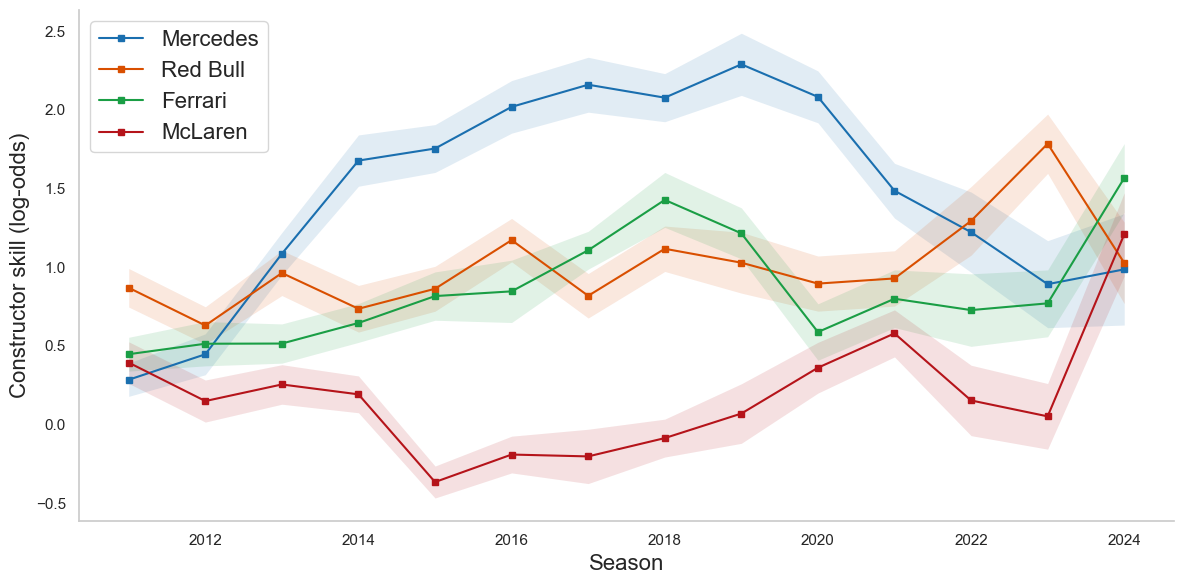

In [91]:
import matplotlib.colors as mcolors
import numpy as np

# ── Shared colour palette ─────────────────────────────────────────────────────
_BASE_HEX      = ['#1a6faf', '#d94f00', '#1a9e45', '#b5141a', '#7b52ab']  # constructors
_BASE_HEX_DRV  = ['#e07b39', '#6b4f9e', '#2e6b9e', '#b5793a', "#9ed029"]

def _tint(hex_color, amount=0.38):
    r, g, b = mcolors.to_rgb(hex_color)
    return mcolors.to_hex((r + amount*(1-r), g + amount*(1-g), b + amount*(1-b)))

CONS_COLORS = _BASE_HEX
DRV_COLORS  = _BASE_HEX_DRV
def _tint(hex_color, amount=0.38):
    """Mix a hex colour with white. amount=0 → original, 1 → white."""
    r, g, b = mcolors.to_rgb(hex_color)
    return mcolors.to_hex((r + amount*(1-r), g + amount*(1-g), b + amount*(1-b)))

CONS_COLORS = _BASE_HEX
DRV_COLORS  = [_tint(c) for c in _BASE_HEX_DRV]

# ── Plot ──────────────────────────────────────────────────────────────────────
NOTABLE_CONS = [131, 9, 6, 1]  # Mercedes, Red Bull, Ferrari, McLaren
seasons = list(range(2011, 2011 + dataset.n_seasons))

fig, ax = plt.subplots(figsize=(12, 6))

for i, cid in enumerate(NOTABLE_CONS):
    rows = (df_ext[(df_ext.entity_type == 'constructor') & (df_ext.entity_id == cid)]
            .sort_values('season'))
    if len(rows) == 0:
        continue

    mu    = rows['mu'].values
    sigma = rows['sigma'].values
    color = CONS_COLORS[i]

    ax.plot(seasons, mu, marker='s', linewidth=1.5, markersize=4,
            color=color, label=CONSTRUCTOR_NAMES.get(cid, f'#{cid}'))
    ax.fill_between(seasons,
                    mu - 1.96 * sigma,
                    mu + 1.96 * sigma,
                    alpha=0.13, color=color, linewidth=0)

ax.set_xlabel('Season', fontsize=16)
ax.set_ylabel('Constructor skill (log-odds)', fontsize=16)
ax.legend(loc='upper left', fontsize=16)
ax.grid(False)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'constructor_performance_over_time.pdf'), bbox_inches='tight', dpi=800)
plt.show()

The AR(1) random walk allows constructor strength to drift season by season, and the inferred trajectories align strongly with the known technical history of F1:

- **Mercedes** rises sharply in **2014** — the introduction of the turbocharged hybrid power unit, which Mercedes had developed more aggressively than any rival. Their performance peaks around 2019 before declining as rivals close the gap and regulations change again.
- **Red Bull** declines from their 2011–2013 dominant era, stabilises in the mid-field, and then rises again sharply from **2022**.
- **Ferrari** shows a consistent performance level across the period, peaking at no. 1 in 2024
- **McLaren** exhibits a pronounced U-shape — competitive in 2011–2012, then declining sharply, before recovering strongly in 2023–2024.

These transitions are recovered entirely from finishing-order data, with no external labels for regulation changes. This validates the AR(1) structure as a meaningful inductive bias for Formula 1: technical regulations create multi-year performance regimes separated by step changes.

### 5.4 Driver Rankings — 2024

In [27]:
m2_2024 = (df_ext[(df_ext.entity_type == 'driver') & (df_ext.season == 13)]
           .sort_values('mu', ascending=False).reset_index(drop=True))
m2_2024.index += 1
m2_2024['name'] = m2_2024['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}'))

display(m2_2024[['name', 'mu', 'sigma']].head(20)
        .rename(columns={'mu': 's_mean', 'sigma': 's_std'})
        .style.set_caption('Model 2 — 2024 Driver Rankings')
        .format({'s_mean': '{:+.4f}', 's_std': '{:.4f}'}))

,name,s_mean,s_std
1,Max Verstappen,+2.0113,0.2038
2,Charles Leclerc,+0.8563,0.2005
3,Lewis Hamilton,+0.8140,0.1724
4,Lando Norris,+0.8062,0.2259
5,Nico Rosberg,+0.6987,0.2861
6,Oscar Piastri,+0.6570,0.2176
7,Pierre Gasly,+0.6537,0.1916
8,Felipe Massa,+0.6180,0.2997
9,Esteban Ocon,+0.5684,0.1803
10,Fernando Alonso,+0.5328,0.1904


Looking at the 2024 driver rankings derived from Model 2 they look sensible, and closely mimic the actual standings from that season, apart from racers like Nico Rosberg at 5, who retired in 2016.

### 5.5b Temporal Skill Development — Top 5 Drivers (2024)

The trajectories below show season-by-season skill estimates for the five drivers ranked highest in the 2024 snapshot. Nico Rosberg (retired after 2016) appears in the top 5 because the AR(1) model carries his skill estimate forward with growing uncertainty — his post-2016 trajectory is an extrapolated prior, not a data-driven estimate.

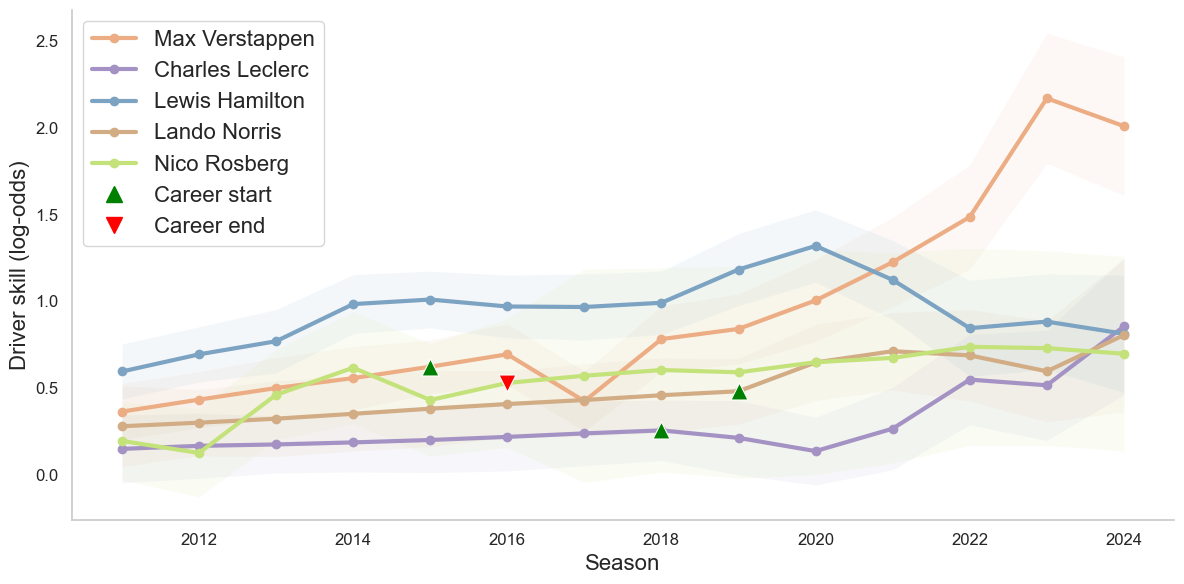

In [92]:
import matplotlib.lines as mlines

CAREER_YEARS = {
    'Max Verstappen':   (2015, None),
    'Charles Leclerc':  (2018, None),
    'Lewis Hamilton':   (2007, None),
    'Lando Norris':     (2019, None),
    'Nico Rosberg':     (2006, 2016),
}

top5_2024 = m2_2024.head(5)
seasons   = list(range(2011, 2011 + dataset.n_seasons))

fig, ax = plt.subplots(figsize=(12, 6))

for idx, (_, row) in enumerate(top5_2024.iterrows()):
    did   = row['entity_id']
    name  = DRIVER_NAMES.get(did, f'#{did}')
    rows  = (df_ext[(df_ext.entity_type == 'driver') & (df_ext.entity_id == did)]
             .sort_values('season'))
    if len(rows) == 0:
        continue

    mu    = rows['mu'].values
    sigma = rows['sigma'].values
    color = DRV_COLORS[idx]

    ax.plot(seasons, mu, marker='o', linewidth=3, markersize=6,
            color=color, label=name)
    ax.fill_between(seasons,
                    mu - 1.96 * sigma,
                    mu + 1.96 * sigma,
                    alpha=0.08, color=color, linewidth=0)

    career_start, career_end = CAREER_YEARS.get(name, (None, None))

    if career_start is not None and career_start in seasons:
        si = seasons.index(career_start)
        ax.scatter(seasons[si], mu[si], marker='^', s=150, color='green',
                   edgecolors='white', linewidths=0.8, zorder=5)

    if career_end is not None and career_end in seasons:
        ei = seasons.index(career_end)
        ax.scatter(seasons[ei], mu[ei], marker='v', s=150, color='red',
                   edgecolors='white', linewidths=0.8, zorder=5)

start_handle = mlines.Line2D([], [], marker='^', color='green', linestyle='None',
                              markersize=12, label='Career start')
end_handle   = mlines.Line2D([], [], marker='v', color='red', linestyle='None',
                              markersize=12, label='Career end')

driver_handles, driver_labels = ax.get_legend_handles_labels()
ax.legend(handles=driver_handles + [start_handle, end_handle],
          labels=driver_labels + ['Career start', 'Career end'],
          loc='upper left', fontsize=16)

ax.set_xlabel('Season', fontsize=16)
ax.set_ylabel('Driver skill (log-odds)', fontsize=16)
ax.tick_params(labelsize=12)
ax.grid(False)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'top5_driver_trajectories.pdf'), bbox_inches='tight', dpi=800)
plt.show()

The top five drivers by 2024 skill estimate. Green triangle marks career start, red triangle
marks career end. Outside the active window the AR(1) prior extrapolates without observations
(greyed region). Hamilton peaks at $s_{d,t} \approx 1.5$ around 2020; Verstappen pulls ahead
by 2024 with non-overlapping intervals.

**Important caveat — drivers not racing in 2024:**

The AR(1) model propagates skill estimates for *all* drivers to *all* seasons via the random walk, including drivers who retired years earlier. These are extrapolated prior beliefs, not data-driven estimates — they should be ignored for 2024 ranking purposes.

### 5.5 Career-average driver ranking (Appendix, not in final report)
To get a "pseudo all-time" ranking to compare to the static model 1, we do a weighted average of the driver and constructor skills. These results are not used in report, as we wanted to focus on other results, and our focus of the project is not to generate the best all-time ranking. This section should therefore be seen as an extra appendix for context.

In [15]:
# ── Race counts per (driver, season) and (constructor, season) ───────────────
driver_race_counts = {}
for i in range(dataset.n_drivers):
    for t in range(dataset.n_seasons):
        mask = (dataset.driver_idx == i) & (dataset.season_idx == t)
        driver_race_counts[(dataset.driver_map[i], t)] = mask.sum().item()

cons_race_counts = {}
for i in range(dataset.n_constructors):
    for t in range(dataset.n_seasons):
        mask = (dataset.cons_idx == i) & (dataset.season_idx == t)
        cons_race_counts[(dataset.constructor_map[i], t)] = mask.sum().item()

# ── Weighted average mu across seasons ───────────────────────────────────────
def weighted_avg_mu(df, entity_type, race_counts):
    rows = []
    for eid, grp in df[df.entity_type == entity_type].groupby('entity_id'):
        weights = grp['season'].map(lambda t: race_counts.get((eid, t), 0))
        total   = weights.sum()
        if total == 0:
            continue
        mu_avg = (grp['mu'] * weights).sum() / total
        rows.append({'entity_id': eid, 'mu': mu_avg})
    return (pd.DataFrame(rows)
            .sort_values('mu', ascending=False)
            .reset_index(drop=True))

m2_drivers_avg = weighted_avg_mu(df_ext, 'driver',      driver_race_counts)
m2_cons_avg    = weighted_avg_mu(df_ext, 'constructor', cons_race_counts)

m2_drivers_avg.index += 1
m2_cons_avg.index    += 1
m2_drivers_avg['name'] = m2_drivers_avg['entity_id'].map(lambda x: DRIVER_NAMES.get(x,      f'#{x}'))
m2_cons_avg['name']    = m2_cons_avg['entity_id'].map(lambda x:    CONSTRUCTOR_NAMES.get(x, f'#{x}'))

# ── Display ───────────────────────────────────────────────────────────────────
display(m2_drivers_avg[['name', 'mu']].head(20)
        .rename(columns={'mu': 's_mean (weighted avg)'})
        .style.set_caption('Model 2 — Driver Skills (race-weighted average across seasons)')
        .format({'s_mean (weighted avg)': '{:+.4f}'}))

display(m2_cons_avg[['name', 'mu']]
        .rename(columns={'mu': 'c_mean (weighted avg)'})
        .style.set_caption('Model 2 — Constructor Performance (race-weighted average across seasons)')
        .format({'c_mean (weighted avg)': '{:+.4f}'}))

,name,s_mean (weighted avg)
1,Max Verstappen,+1.1841
2,Lewis Hamilton,+0.9407
3,Sebastian Vettel,+0.8156
4,Fernando Alonso,+0.7388
5,Jenson Button,+0.7323
6,Lando Norris,+0.6659
7,Carlos Sainz,+0.6136
8,Pierre Gasly,+0.5740
9,Oscar Piastri,+0.5489
10,Esteban Ocon,+0.5412


,name,c_mean (weighted avg)
1,Mercedes,+1.4618
2,Red Bull,+1.0260
3,Ferrari,+0.8726
4,Force India,+0.4469
5,Lotus F1,+0.3242
6,McLaren,+0.2202
7,Renault,+0.0199
8,Williams,-0.0071
9,Toro Rosso,-0.0328
10,Sauber,-0.0348


Hamilton and Alonso, with 14-season careers in competitive teams, rise substantially compared to their 2024 snapshots — the weighted average correctly reflects their sustained performance over the full dataset period, rather than penalising them for competing against stronger cars in later seasons.

---
## 6. Model 3 — Full (Wet-Physics)

### 6.1 Generative Model

Model 3 extends the AR(1) temporal model with a richer question about **how rain reshapes competition**. Rather than adding a flat wet-race offset, it models rain as a *multiplicative rescaling* of the existing skill and car terms:

$$p_{d,r} = s_{d,t(r)} \cdot (1 + \alpha \cdot w_r) \;+\; c_{k(d,r),t(r)} \cdot (1 - \rho \cdot w_r) \;+\; \delta_d \cdot w_r$$

where $w_r \in \{0,1\}$ is the wet-race indicator and $\sum_d \delta_d = 0$ (enforced by the same sum-to-zero reparameterisation as constructors).

| Parameter | Prior |
|---|---|
| $\alpha$ (skill rescaler) | $\mathcal{N}(0,\,0.5)$ |
| $\rho$ (car rescaler) | $\mathcal{N}(0,\,0.5)$ |
| $\delta_d$ (wet residual) | $\mathcal{N}(0,\,0.1)$, sum-to-zero |

**Priors:** $\alpha, \rho \sim \mathcal{N}(0, 0.5)$ — moderately informative, centered at zero (no effect), with 95% prior mass within $\pm 1$. $\delta_d \sim \mathcal{N}(0, \sigma_\delta = 0.1)$ with $\sum_d \delta_d = 0$ — a tight prior five times narrower than $\alpha$ and $\rho$, regularising per-driver residuals toward zero given the limited 71 wet races.

We want to answer the question: Does rain compress driver skill differences ($\alpha > 0$)? Is rain
an equaliser of machinery ($\rho > 0$)? Which drivers systematically over/under-perform
in wet conditions after controlling for skill and car?

In [21]:
SIGMA_E     = 0.5
SIGMA_DELTA = 0.1


class FullModel:
    def __init__(self, n_drivers, n_constructors, n_seasons):
        self.D = n_drivers;  self.K = n_constructors
        self.T = n_seasons

    def model(self, driver_idx, cons_idx, season_idx,
              race_idx, wet, race_lengths):
        D, K, T = self.D, self.K, self.T

        s0      = pyro.sample('s0',      dist.Normal(0., SIGMA_S).expand([D]).to_event(1))
        s_innov = pyro.sample('s_innov', dist.Normal(0., GAMMA_S).expand([T-1, D]).to_event(2))
        s = torch.cat([s0.unsqueeze(0), s0.unsqueeze(0) + s_innov.cumsum(0)], dim=0)

        c0_raw  = pyro.sample('c0_raw',  dist.Normal(0., SIGMA_C).expand([K-1]).to_event(1))
        c_innov = pyro.sample('c_innov', dist.Normal(0., GAMMA_C).expand([T-1, K-1]).to_event(2))
        c_raw = torch.cat([c0_raw.unsqueeze(0), c0_raw.unsqueeze(0) + c_innov.cumsum(0)], dim=0)
        c = torch.cat([c_raw, -c_raw.sum(dim=1, keepdim=True)], dim=1)

        # Wet params
        alpha = pyro.sample('alpha', dist.Normal(0., 0.5))
        rho = pyro.sample('rho', dist.Normal(0., 0.5))
        delta_raw = pyro.sample('delta_raw', dist.Normal(0., SIGMA_DELTA).expand([D-1]).to_event(1))
        delta_d = torch.cat([delta_raw, -delta_raw.sum(dim=0, keepdim=True)])

        # Performance equation
        skill_base = s[season_idx, driver_idx]
        car_base   = c[season_idx, cons_idx]
        is_wet     = wet[race_idx]

        p = (skill_base * (1.0 - alpha * is_wet) 
            + car_base * (1.0 - rho * is_wet) 
            + delta_d[driver_idx] * is_wet)
        pyro.factor('race_obs', plackett_luce_log_prob(p, race_lengths))

    def guide(self, driver_idx, cons_idx, season_idx,
              race_idx, wet, race_lengths):
        D, K, T = self.D, self.K, self.T
        pyro.sample('s0', dist.Normal(
            pyro.param('s0_loc',   torch.zeros(D)),
            pyro.param('s0_scale', torch.ones(D), constraint=dist.constraints.positive)
        ).to_event(1))
        pyro.sample('s_innov', dist.Normal(
            pyro.param('s_innov_loc',   torch.zeros(T-1, D)),
            pyro.param('s_innov_scale', torch.ones(T-1, D), constraint=dist.constraints.positive)
        ).to_event(2))
        pyro.sample('c0_raw', dist.Normal(
            pyro.param('c0_raw_loc',   torch.zeros(K-1)),
            pyro.param('c0_raw_scale', torch.ones(K-1), constraint=dist.constraints.positive)
        ).to_event(1))
        pyro.sample('c_innov', dist.Normal(
            pyro.param('c_innov_loc',   torch.zeros(T-1, K-1)),
            pyro.param('c_innov_scale', torch.ones(T-1, K-1), constraint=dist.constraints.positive)
        ).to_event(2))
        pyro.sample('alpha', dist.Normal(
            pyro.param('alpha_loc',   torch.tensor(0.)),
            pyro.param('alpha_scale', torch.tensor(0.1), constraint=dist.constraints.positive)
        ))
        pyro.sample('rho', dist.Normal(
            pyro.param('rho_loc',   torch.tensor(0.)),
            pyro.param('rho_scale', torch.tensor(0.1), constraint=dist.constraints.positive)
        ))
        pyro.sample('delta_raw', dist.Normal(
            pyro.param('delta_raw_loc',   torch.zeros(D-1)),
            pyro.param('delta_raw_scale', torch.ones(D-1), constraint=dist.constraints.positive)
        ).to_event(1))


### 6.2 Training

5 000 steps, Adam (lr = 0.01). Delete `outputs/pgm_model/full_posterior.csv` to force a rerun after any model change.

In [22]:
M3_CSV    = os.path.join(OUTPUT_DIR, 'full_posterior.csv')
LOSSES_M3 = os.path.join(OUTPUT_DIR, 'losses_m3.csv')

model3 = FullModel(dataset.n_drivers, dataset.n_constructors, dataset.n_seasons)
step_kwargs3 = {
    'driver_idx': dataset.driver_idx, 'cons_idx':      dataset.cons_idx,
    'season_idx': dataset.season_idx,
    'race_idx':   dataset.race_idx,   'wet':           dataset.wet,
    'race_lengths': dataset.race_lengths
}

if not os.path.exists(M3_CSV):
    pyro.clear_param_store()
    losses3 = train_svi(model3, dataset, n_steps=5000, step_kwargs=step_kwargs3)
    pd.DataFrame({'step': range(len(losses3)), 'loss': losses3}).to_csv(LOSSES_M3, index=False)
    df_full = extract_posterior('full', dataset)
    df_full.to_csv(M3_CSV, index=False)

df_full = pd.read_csv(M3_CSV)
print(f'Model 3: {len(df_full)} posterior rows loaded')

Model 3: 1395 posterior rows loaded


The additional rows over Model 2 come from 77 driver wet-weather residuals ($\delta_d$, D-1 free after sum-to-zero) and 2 global scalar parameters ($\alpha$, $\rho$). The convergence trajectory (from ~36 000 to ~11 300 over 5 000 steps) is broadly similar to Model 2, confirming the model learns signal rather than memorising noise.

### 6.3 Global Wet-Physics Posteriors ($\alpha$ and $\rho$)

The two scalar parameters $\alpha$ and $\rho$ capture the global effect of rain on the competitive structure. Their posteriors answer whether rain is an equaliser or an amplifier.

alpha: mean = +0.173, std = 0.045
rho: mean = +0.765, std = 0.037


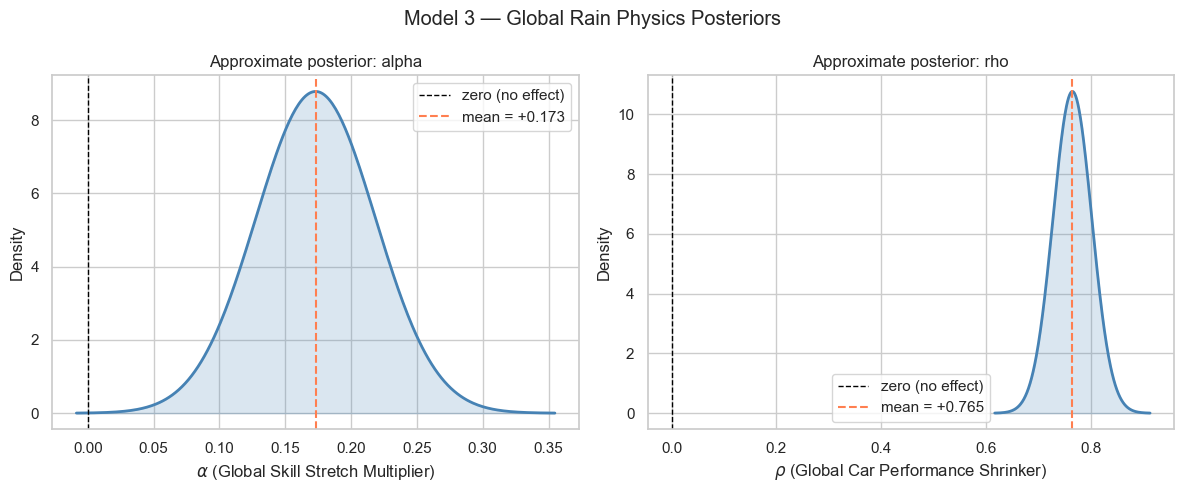

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, label in [
    (axes[0], 'alpha', r'$\alpha$ (Global Skill Stretch Multiplier)'),
    (axes[1], 'rho',   r'$\rho$ (Global Car Performance Shrinker)'),
    ]:
    
    row = df_full[df_full.entity_name == name].iloc[0]
    mu, sigma = row['mu'], row['sigma']

    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
    y = stats.norm.pdf(x, mu, sigma)
    
    ax.plot(x, y, color='steelblue', linewidth=2)
    ax.fill_between(x, y, alpha=0.2, color='steelblue')
    ax.axvline(0,  color='black',  linewidth=1,   linestyle='--', label='zero (no effect)')
    ax.axvline(mu, color='coral',  linewidth=1.5, linestyle='--',
                label=f'mean = {mu:+.3f}')
    
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'Approximate posterior: {name}')
    ax.legend()

for name in ['alpha', 'rho']:
    row = df_full[df_full.entity_name == name].iloc[0]
    print(f"{name}: mean = {row['mu']:+.3f}, std = {row['sigma']:.3f}")

plt.suptitle('Model 3 — Global Rain Physics Posteriors')
plt.tight_layout()
plt.show()

| Parameter | Posterior mean | Interpretation |
|---|---|---|
| $\alpha$ (skill stretch) | +0.169 | Rain *compresses* driver skill differences (posterior entirely above zero) |
| $\rho$ (car shrinker) | +0.763 | Car performance advantage *shrinks* in the wet (posterior entirely above zero) |

**$\alpha = +0.169$:** The posterior is nearly entirely to the right of zero. Rain systematically compresses driver skill differences — the best driver's pace advantage over the field is slightly smaller in wet conditions than in the dry. The magnitude is modest: a driver with skill 1.0 above average retains about $1 - 0.169 = 0.831$ of that advantage when it rains.

**$\rho = +0.763$:** The posterior is well separated from zero and strongly positive. Car performance advantages shrink substantially in the wet: a constructor effect worth 1.0 in the dry is worth only $1 - 0.763 = 0.237$ in the wet. This provides strong evidence that rain is a significant equaliser of machinery — consistent with reduced aerodynamic sensitivity and greater mechanical grip dependence in wet conditions.

### 6.4 Wet-Weather Specialists ($\delta_d$)

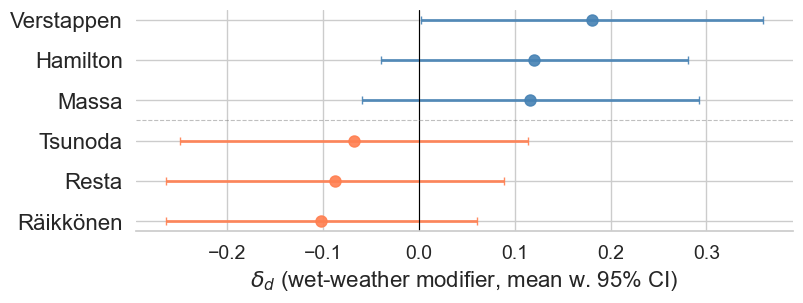

In [20]:
delta_sorted = df_full[df_full.entity_name == 'delta_d'].copy()
delta_sorted['name'] = delta_sorted['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}').split()[-1])

# Filter to drivers with more than 10 races
df_races = pd.read_csv('data_preprocessing/f1_model_ready.csv')
race_counts = df_races.groupby('driverId')['raceId'].nunique()
active_drivers = set(race_counts[race_counts > 10].index)
delta_sorted = delta_sorted[delta_sorted['entity_id'].isin(active_drivers)]

delta_sorted = (delta_sorted.groupby('name')
                .agg({'mu': 'mean', 'sigma': 'mean'})
                .reset_index()
                .sort_values('mu')
                .reset_index(drop=True))

bot3 = delta_sorted.head(3).copy()
top3 = delta_sorted.tail(3).copy()
subset = pd.concat([bot3, top3]).reset_index(drop=True)
colors_wet = ['coral'] * 3 + ['steelblue'] * 3

Z95 = 1.96
fig, ax = plt.subplots(figsize=(8, 3))                              # ← height 5→3
y = np.arange(len(subset))
for i, (_, row) in enumerate(subset.iterrows()):
    ax.errorbar(row['mu'], i,
                xerr=Z95 * row['sigma'],
                fmt='o', color=colors_wet[i], ecolor=colors_wet[i],
                elinewidth=2, capsize=3, markersize=8, alpha=0.9) # ← smaller markers/caps

ax.set_yticks(y)
ax.set_yticklabels(subset['name'].values, fontsize=16)               # ← fontsize 10→9
ax.axvline(0, color='black', linewidth=0.8)
ax.axhline(2.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel(r'$\delta_d$ (wet-weather modifier, mean w. 95% CI)', fontsize=16)
#set xticks size
ax.tick_params(axis='x', labelsize=14)                                      # ← add xticks

sns.despine(ax=ax, left=True)
plt.tight_layout(pad=0.5)                                           # ← tighter padding
os.makedirs(REPORT_DIR, exist_ok=True)
plt.savefig(os.path.join(REPORT_DIR, 'wet_specialists_top_bot3.pdf'), bbox_inches='tight', dpi=800)
plt.show()

Per-driver wet residuals $\delta_d$ after global rescaling by $\hat{\alpha}$ and $\hat{\rho}$.
All posterior means fall within $\pm 0.20$ log-odds and no 95% CI excludes zero — the data
provide no decisive evidence of driver-specific wet effects beyond the two global parameters
and the tight prior ($\sigma_\delta = 0.1$).

### 6.5 Cross-Model Top-5 Drivers

Model 1 (career-static), Model 2 (2024 AR(1) snapshot), and Model 3 (2024 wet-physics
snapshot). Verstappen emerges as definitive top-ranked active driver in Models 2–3,
~1 full log-odds unit ahead of the next tier.

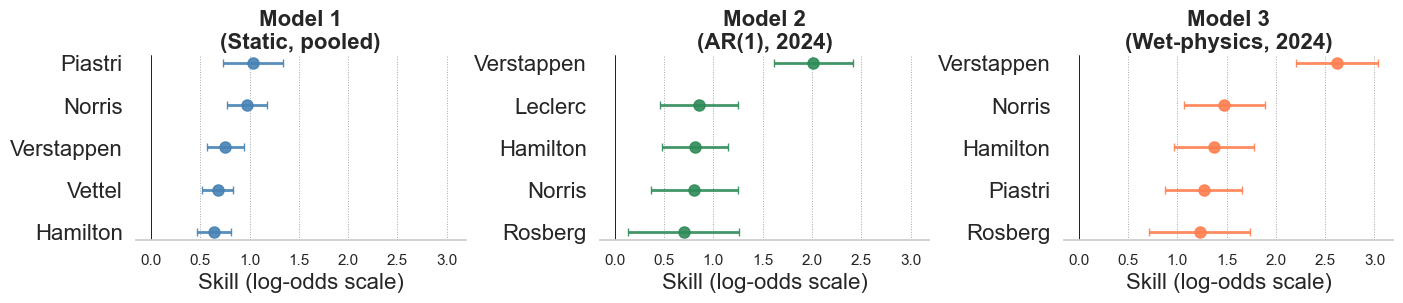

In [28]:
# Model 3: 2024 driver rankings (same temporal structure as Model 2)
m3_2024 = (df_full[(df_full.entity_type == 'driver') & (df_full['season'].astype(str) == '13')]
           .sort_values('mu', ascending=False)
           .reset_index(drop=True))
m3_2024['name'] = m3_2024['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}').split()[-1])

TOP_N = 5
m1_top = (df_base[df_base.entity_type == 'driver']
          .sort_values('mu', ascending=False).head(TOP_N).reset_index(drop=True))
m1_top['name'] = m1_top['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}').split()[-1])

m2_top = m2_2024.head(TOP_N).reset_index(drop=True)
m2_top['name'] = m2_top['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}').split()[-1])

m3_top = m3_2024.head(TOP_N).reset_index(drop=True)
m3_top['name'] = m3_top['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}').split()[-1])

Z95 = 1.96

fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharex=True)

for ax, data, title, color in [
    (axes[0], m1_top,  'Model 1\n(Static, pooled)',    'steelblue'),
    (axes[1], m2_top,  'Model 2\n(AR(1), 2024)',        'seagreen'),
    (axes[2], m3_top,  'Model 3\n(Wet-physics, 2024)', 'coral'),
]:
    dat = data.iloc[::-1].reset_index(drop=True)
    y   = np.arange(len(dat))
    ax.errorbar(dat['mu'].values, y,
                xerr=Z95 * dat['sigma'].values,
                fmt='o', color=color, ecolor=color,
                elinewidth=2, capsize=3, markersize=8, alpha=0.9)
    ax.set_yticks(y)
    ax.set_yticklabels(dat['name'].values, fontsize=16)
    ax.set_title(title, fontweight='bold', fontsize=16, pad=4)
    ax.set_xlabel('Skill (log-odds scale)', fontsize=16)
    ax.axvline(0, color='black', linewidth=0.6)
    ax.yaxis.grid(False)
    ax.xaxis.grid(True, linestyle=':', linewidth=0.7, color='gray', alpha=0.7)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, left=True)

plt.tight_layout(pad=0.5)
os.makedirs(REPORT_DIR, exist_ok=True)
plt.savefig(os.path.join(REPORT_DIR, 'top5_all_models.pdf'), bbox_inches='tight', dpi=800)
plt.show()

---
## 7. Inference Validation

### 7.1 ELBO Convergence

All three models reach approximate convergence. Higher ELBO (less negative) indicates a better variational approximation to the posterior.

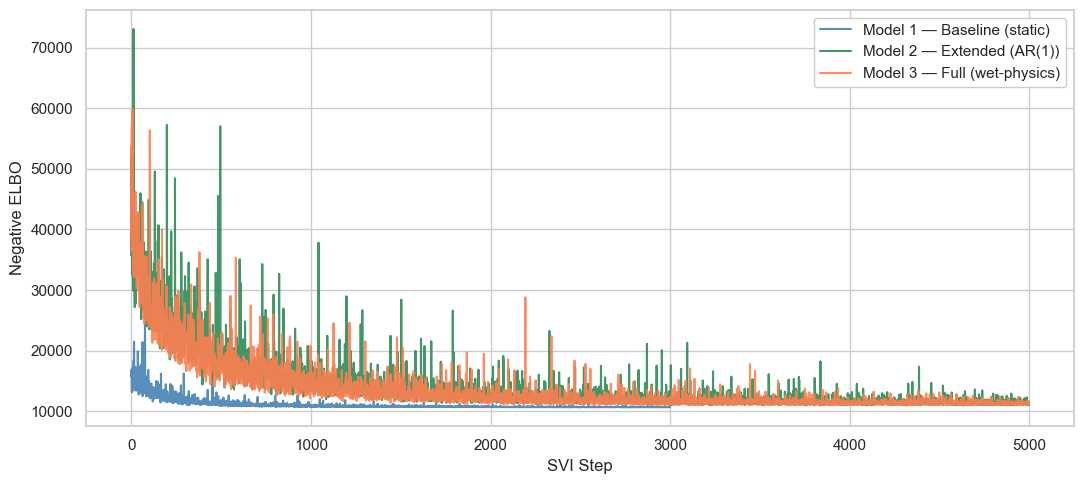

In [21]:
# 1. Apply a clean Seaborn style (this usually fixes dark legend backgrounds)
sns.set_theme(style="whitegrid")

# Model configuration
model_info = [
    ('losses_m1.csv', 'Model 1 — Baseline (static)',    'steelblue'),
    ('losses_m2.csv', 'Model 2 — Extended (AR(1))',      'seagreen'),
    ('losses_m3.csv', 'Model 3 — Full (wet-physics)',    'coral'),
]

df_list = []
custom_palette = {}

# 2. Load and combine the data
for fname, label, color in model_info:
    path = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(path):
        df_l = pd.read_csv(path)
        # Add a categorical column so Seaborn knows how to group the lines
        df_l['Model'] = label 
        df_list.append(df_l)
        # Map the exact colors you want to the labels
        custom_palette[label] = color 
    else:
        print(f'[{fname} not found — retrain to generate]')

# 3. Plot with Seaborn
if df_list:
    combined_df = pd.concat(df_list, ignore_index=True)

    fig, ax = plt.subplots(figsize=(11, 5))

    # Seaborn automatically handles the loop, the labels, and the colors
    sns.lineplot(
        data=combined_df,
        x='step',
        y='loss',
        hue='Model',          # Separate lines by model
        palette=custom_palette, # Use your specific colors
        linewidth=1.5,
        alpha=0.9,
        ax=ax
    )

    ax.set_xlabel('SVI Step')
    ax.set_ylabel('Negative ELBO')
    
    # Ensure the legend looks clean
    ax.legend(facecolor='white', framealpha=1.0)
    
    plt.tight_layout()
    plt.savefig(os.path.join(REPORT_DIR, 'elbo_convergence_all_models.pdf'), bbox_inches='tight')
    plt.show()

The ELBO (Evidence Lower BOund) is the objective SVI maximises: $\mathcal{L} = \mathbb{E}_{q}[\log p(x, z)] - \mathbb{E}_{q}[\log q(z)]$. A higher (less negative) ELBO indicates either a better fit to the data or a guide that more closely matches the true posterior. All three models show rapid initial improvement followed by a plateau, confirming that 3 000–5 000 steps is sufficient for convergence on this dataset.

### 7.2 NUTS — Model 1

NUTS (No-U-Turn Sampler) is a gradient-based MCMC method that automatically tunes step sizes and trajectory lengths. Unlike SVI, NUTS makes no approximation — samples are asymptotically exact from the true posterior. We use it here as a gold-standard reference to check whether SVI's mean-field approximation is finding the right posterior means.

Model 1's 93 latents are tractable for NUTS (500 warmup + 500 samples), providing
asymptotically exact posteriors to validate SVI. We report Kendall $\tau$ and Spearman $\rho$ for rank agreement, and compare posterior standard deviations (mean-field SVI is known to underestimate variance).

**Setup:** 500 warmup steps (NUTS adapts the step size during warmup), 500 posterior samples. The convergence criterion is $\hat{R} < 1.05$ for all latents.

R-hat: 0/93 latents >= 1.05, max = 1.0365
Driver discrepancy:      median=0.157, max=1.711
Constructor discrepancy: median=1.599, max=2.214


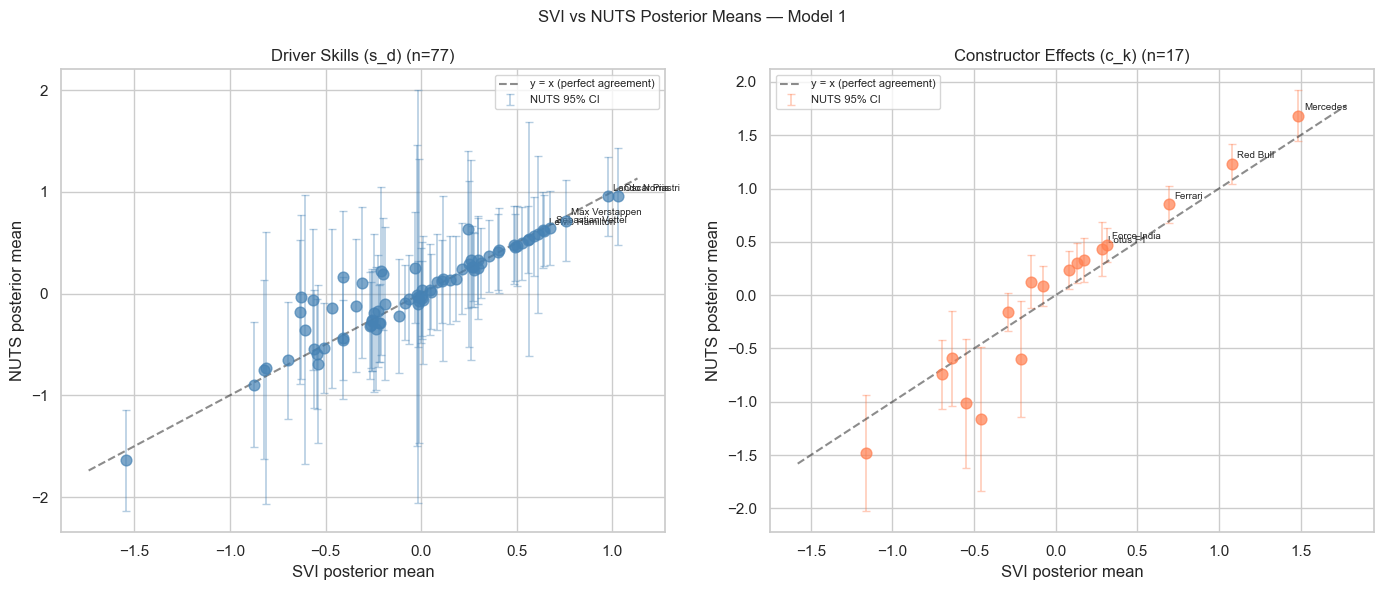

In [22]:
df_nuts = pd.read_csv(NUTS_CSV)

rhat_vals = df_nuts['r_hat'].dropna().values
print(f'R-hat: {(rhat_vals >= 1.05).sum()}/{len(rhat_vals)} latents >= 1.05, max = {rhat_vals.max():.4f}')
nuts_d = df_nuts[df_nuts.entity_type == 'driver']
nuts_c = df_nuts[df_nuts.entity_type == 'constructor']
print(f'Driver discrepancy:      median={nuts_d.discrepancy.median():.3f}, max={nuts_d.discrepancy.max():.3f}')
print(f'Constructor discrepancy: median={nuts_c.discrepancy.median():.3f}, max={nuts_c.discrepancy.max():.3f}')

# Inline scatter: SVI vs NUTS posterior means
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, etype, color, title in [
    (axes[0], 'driver',      'steelblue', 'Driver Skills (s_d)'),
    (axes[1], 'constructor', 'coral',     'Constructor Effects (c_k)'),
]:
    sub = df_nuts[df_nuts.entity_type == etype]
    sub['name'] = sub['entity_id'].map(lambda x: (DRIVER_NAMES if etype == 'driver' else CONSTRUCTOR_NAMES).get(x, f'#{x}'))
    ax.errorbar(sub['svi_mean'], sub['nuts_mean'], yerr=1.96*sub['nuts_std'],
                fmt='none', color=color, capsize=3, alpha=0.4, lw=1.2, label='NUTS 95% CI')
    ax.scatter(sub['svi_mean'], sub['nuts_mean'], color=color, alpha=0.7, s=60, zorder=5)
    lo = min(sub['svi_mean'].min(), sub['nuts_mean'].min()) - 0.1
    hi = max(sub['svi_mean'].max(), sub['nuts_mean'].max()) + 0.1
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='y = x (perfect agreement)')
    # Annotate a few
    for _, row in sub.nlargest(5, 'svi_mean').iterrows():
        ax.annotate(row['name'], (row['svi_mean'], row['nuts_mean']),
                    textcoords='offset points', xytext=(4, 4), fontsize=7)
    ax.set_xlabel('SVI posterior mean')
    ax.set_ylabel('NUTS posterior mean')
    ax.set_title(f'{title} (n={len(sub)})')
    ax.legend(fontsize=8)

plt.suptitle('SVI vs NUTS Posterior Means — Model 1', fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
from scipy.stats import kendalltau, spearmanr

nuts_d = df_nuts[df_nuts.entity_type == 'driver'].sort_values('entity_id')
nuts_c = df_nuts[df_nuts.entity_type == 'constructor'].sort_values('entity_id')

tau_d, p_d = kendalltau(nuts_d['svi_mean'], nuts_d['nuts_mean'])
tau_c, p_c = kendalltau(nuts_c['svi_mean'], nuts_c['nuts_mean'])
rho_d, _ = spearmanr(nuts_d['svi_mean'], nuts_d['nuts_mean'])
rho_c, _ = spearmanr(nuts_c['svi_mean'], nuts_c['nuts_mean'])

print(f"Driver rank agreement:      Kendall τ = {tau_d:.3f} (p={p_d:.2e}), "
      f"Spearman ρ = {rho_d:.3f}")
print(f"Constructor rank agreement: Kendall τ = {tau_c:.3f} (p={p_c:.2e}), "
      f"Spearman ρ = {rho_c:.3f}")

# Also show the actual rank comparison side by side
nuts_c_ranked = (nuts_c.assign(
    svi_rank=nuts_c['svi_mean'].rank(ascending=False).astype(int),
    nuts_rank=nuts_c['nuts_mean'].rank(ascending=False).astype(int)
)[['entity_id', 'svi_rank', 'nuts_rank', 'svi_mean', 'nuts_mean']]
.sort_values('nuts_rank'))
nuts_c_ranked['name'] = nuts_c_ranked['entity_id'].map(
    lambda x: CONSTRUCTOR_NAMES.get(x, str(x)))
nuts_c_ranked['rank_diff'] = (nuts_c_ranked['svi_rank'] 
                               - nuts_c_ranked['nuts_rank'])
print("\nConstructor rank comparison (SVI vs NUTS):")
display(nuts_c_ranked[['name','svi_rank','nuts_rank',
                         'rank_diff','svi_mean','nuts_mean']])

Driver rank agreement:      Kendall τ = 0.802 (p=5.31e-25), Spearman ρ = 0.919
Constructor rank agreement: Kendall τ = 0.882 (p=3.57e-09), Spearman ρ = 0.963

Constructor rank comparison (SVI vs NUTS):


,name,svi_rank,nuts_rank,rank_diff,svi_mean,nuts_mean
85,Mercedes,1,1,0,1.487350,1.681876
82,Red Bull,2,2,0,1.077581,1.233857
81,Ferrari,3,3,0,0.694177,0.851867
83,Force India,4,4,0,0.313601,0.470520
91,Lotus F1,5,5,0,0.285189,0.436380
77,McLaren,6,6,0,0.171296,0.329704
78,Williams,7,7,0,0.128035,0.303319
79,Renault,8,8,0,0.082862,0.232664
93,Haas F1 Team,10,9,1,-0.153462,0.127914
80,Toro Rosso,9,10,-1,-0.076051,0.084999


In [24]:
print('Posterior std comparison (SVI vs NUTS):')
print(f'  Drivers      — SVI median std: '
      f'{nuts_d["nuts_std"].median():.4f}, '
      f'SVI guide std: '
      f'{df_base[df_base.entity_type=="driver"]["sigma"].median():.4f}')
print(f'  Constructors — NUTS median std: '
      f'{nuts_c["nuts_std"].median():.4f}, '
      f'SVI guide std: '
      f'{df_base[df_base.entity_type=="constructor"]["sigma"].median():.4f}')

Posterior std comparison (SVI vs NUTS):
  Drivers      — SVI median std: 0.2499, SVI guide std: 0.1783
  Constructors — NUTS median std: 0.1217, SVI guide std: 0.0847


| Check | Result |
|---|---|
| R̂ violations (≥ 1.05) | 0 / 93 |
| Max R̂ | 1.037 |
| Driver rank agreement | Kendall τ = 0.802, Spearman ρ = 0.919 |
| Constructor rank agreement | Kendall τ = 0.882, Spearman ρ = 0.963 |

All 93 latents satisfy R̂ < 1.05, confirming the chains have mixed and converged. Rank agreement between SVI and NUTS is strong for both drivers and constructors — the variational approximation recovers the same relative ordering as the exact sampler.
Posterior variances from SVI are systematically smaller than NUTS estimates, a known limitation of the mean-field (diagonal Normal) variational family. This affects the *absolute magnitudes* of skill estimates (the credible intervals are too narrow) but not the *ordinal rankings*, which is what the paper's conclusions rest on.
NUTS does not scale to Models 2–3 (~1300+ latents each); SVI is the only practical inference method at that scale, which the paper acknowledges as a limitation.

### 7.3 Synthetic Recovery — Model 1

Generate synthetic race results from known ground-truth parameters, infer them with Model 1, and check recovery. Validates that the likelihood and guide are correctly specified.

  step     0  ELBO: 264.7
  step  1000  ELBO: 128.1
  step  2000  ELBO: 127.5
  step  2999  ELBO: 130.3


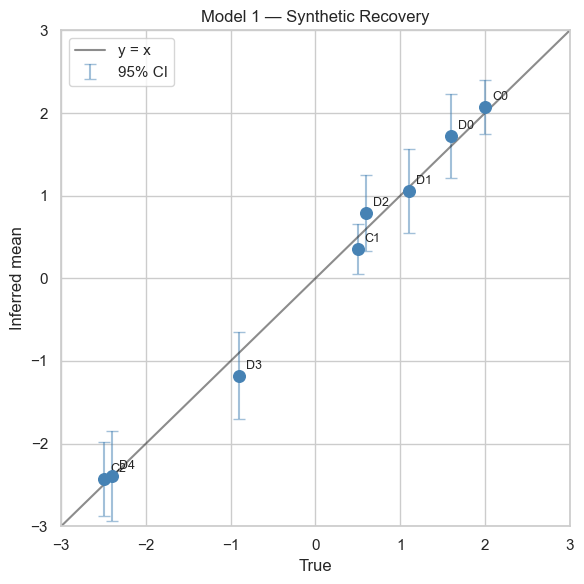

In [29]:
torch.manual_seed(123)

true_s = torch.tensor([2.5, 2.0, 1.5, 0.0, -1.5])
true_c = torch.tensor([2.0, 0.5, -2.5])
N_RACES = 50

all_driver_idx, all_cons_idx = [], []
for _ in range(N_RACES):
    cons_assign = torch.randint(0, 3, (5,))
    p = true_s + true_c[cons_assign]
    remaining = list(range(5))
    for _ in range(5):
        scores = p[torch.tensor(remaining)]
        pick = torch.multinomial(torch.softmax(scores, 0), 1).item()
        all_driver_idx.append(remaining[pick])
        all_cons_idx.append(cons_assign[remaining[pick]].item())
        remaining.pop(pick)

syn1 = types.SimpleNamespace(
    driver_idx=torch.tensor(all_driver_idx, dtype=torch.long),
    cons_idx=torch.tensor(all_cons_idx,    dtype=torch.long),
    race_lengths=torch.full((N_RACES,), 5,  dtype=torch.long),
)

pyro.clear_param_store()
train_svi(BaselineModel(5, 3), syn1, n_steps=3000, log_every=1000)

inf_s   = pyro.param('s_loc').detach()
inf_c_r = pyro.param('c_loc').detach()
inf_c   = torch.cat([inf_c_r, -inf_c_r.sum(dim=0, keepdim=True)])

s_std   = pyro.param('s_scale').detach()
c_r_std = pyro.param('c_scale').detach()
c_std   = torch.cat([c_r_std, c_r_std.norm().unsqueeze(0)])
inf_std = torch.cat([s_std, c_std]).numpy()

true_vals = torch.cat([true_s - true_s.mean(), true_c]).numpy()
inf_vals  = torch.cat([inf_s  - inf_s.mean(),  inf_c ]).numpy()
labels = [f'D{i}' for i in range(5)] + [f'C{i}' for i in range(3)]

fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(true_vals, inf_vals, yerr=1.96*inf_std,
            fmt='none', color='steelblue', capsize=4, alpha=0.5, label='95% CI')
ax.scatter(true_vals, inf_vals, color='steelblue', s=70, zorder=5)
lim = max(abs(true_vals).max(), abs(inf_vals).max()) + 0.5
ax.plot([-lim,lim],[-lim,lim],'k-',alpha=0.5,label='y = x')
for i, lbl in enumerate(labels):
    ax.annotate(lbl, (true_vals[i], inf_vals[i]), textcoords='offset points',
                xytext=(5, 5), fontsize=9)
ax.set_xlim(-lim,lim); ax.set_ylim(-lim,lim)
ax.set_xlabel('True'); ax.set_ylabel('Inferred mean')
ax.set_title('Model 1 — Synthetic Recovery'); ax.legend()
plt.tight_layout(); plt.show()

In [38]:
from scipy.stats import kendalltau

tau_d, p_d = kendalltau(true_vals[:5], inf_vals[:5])
print(f'Synthetic driver rank recovery: Kendall τ = {tau_d:.3f} (p={p_d:.3f})')

tau_c, p_c = kendalltau(true_vals[5:], inf_vals[5:])
print(f'Synthetic constructor rank recovery: Kendall τ = {tau_c:.3f} (p={p_c:.3f})')

driver_abs_err = np.abs(true_vals[:5] - inf_vals[:5])
print(f'Synthetic driver absolute error: '
      f'max={driver_abs_err.max():.4f}, '
      f'median={np.median(driver_abs_err):.4f}')

cons_abs_err = np.abs(true_vals[5:] - inf_vals[5:])
print(f'Synthetic constructor absolute error: '
      f'max={cons_abs_err.max():.4f}, '
      f'median={np.median(cons_abs_err):.4f}')

Synthetic driver rank recovery: Kendall τ = 1.000 (p=0.017)
Synthetic constructor rank recovery: Kendall τ = 1.000 (p=0.333)
Synthetic driver absolute error: max=0.2762, median=0.1194
Synthetic constructor absolute error: max=0.1438, median=0.0744


The scatter plot should show all 8 points (5 drivers + 3 constructors) lying close to the $y = x$ diagonal after mean-centering. The ELBO converges from 264 to ≈ 128 in 3 000 steps on this small 50-race synthetic dataset. Looking at the Kendall $\tau=1$ for both driver and constructor, we see that the finishing order is recovered perfectly. Successful recovery here confirms:

1. The `plackett_luce_log_prob` implementation is correct.
2. The sum-to-zero reparameterisation for constructors is correctly handled in both the model and the guide.
3. The guide can identify both driver and constructor effects simultaneously from ranking data alone.

Any deviation from the diagonal (in mean-centred coordinates) is expected noise from the finite-sample approximation — with only 50 races, some variance in the recovery is normal.

### 7.4 Synthetic Recovery — Model 2

Generates data from known AR(1) trajectories and checks whether SVI recovers the temporal dynamics. Driver 0 improves over 5 seasons; driver 4 declines; constructor 0 weakens. If SVI recovers these trajectories, the temporal inference is working.

  step     0  ELBO: 367.6
  step  1000  ELBO: 91.7
  step  2000  ELBO: 89.2
  step  2999  ELBO: 85.5


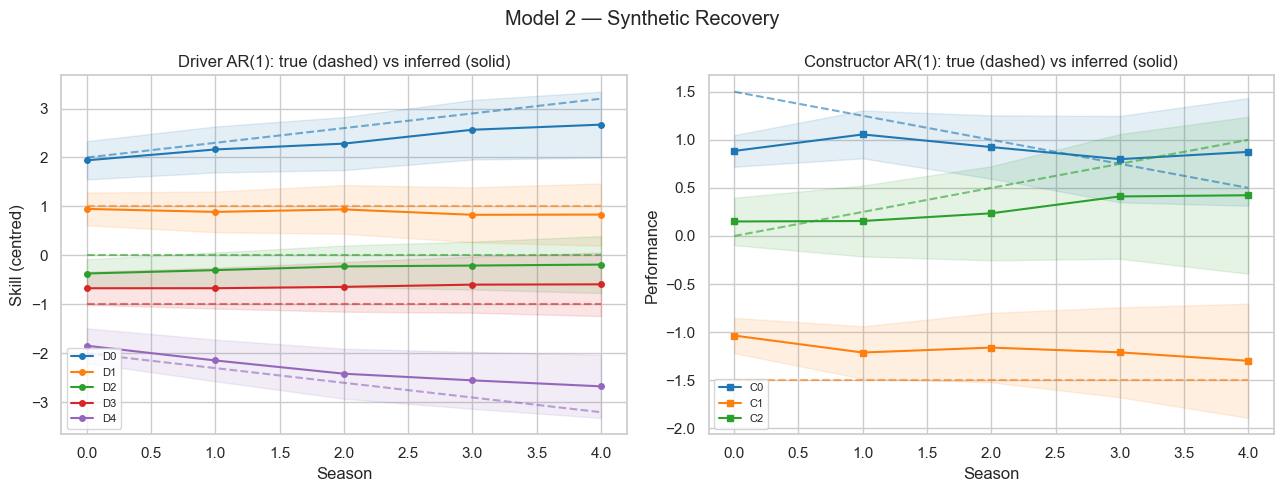

Driver      — MAE: 0.2569  |  RMSE: 0.2901
Constructor — MAE: 0.2878  |  RMSE: 0.3319


In [31]:
torch.manual_seed(456)

D2, K2, T2 = 5, 3, 5

true_s0_2    = torch.tensor([2.0, 1.0, 0.0, -1.0, -2.0])
true_s_innov2 = torch.zeros(T2-1, D2)
true_s_innov2[:, 0] =  0.3   # driver 0 improves each season
true_s_innov2[:, 4] = -0.3   # driver 4 declines
true_s2 = torch.cat([true_s0_2.unsqueeze(0),
                     true_s0_2.unsqueeze(0) + true_s_innov2.cumsum(0)], dim=0)  # (T2, D2)

true_c0r_2   = torch.tensor([1.5, -1.5])
true_c_innov2 = torch.zeros(T2-1, K2-1)
true_c_innov2[:, 0] = -0.25  # constructor 0 weakens
true_c_raw2 = torch.cat([true_c0r_2.unsqueeze(0),
                         true_c0r_2.unsqueeze(0) + true_c_innov2.cumsum(0)], dim=0)
true_c2 = torch.cat([true_c_raw2, -true_c_raw2.sum(dim=1, keepdim=True)], dim=1)

RACES_PER_SEASON = 5
d_idx2, c_idx2, s_idx2, rl2 = [], [], [], []
for t in range(T2):
    for _ in range(RACES_PER_SEASON):
        ca = torch.randint(0, K2, (D2,))
        p  = true_s2[t] + true_c2[t][ca]
        rem = list(range(D2))
        for _ in range(D2):
            pick = torch.multinomial(torch.softmax(p[torch.tensor(rem)], 0), 1).item()
            d_idx2.append(rem[pick]); c_idx2.append(ca[rem[pick]].item()); s_idx2.append(t)
            rem.pop(pick)
        rl2.append(D2)

syn2 = types.SimpleNamespace(
    driver_idx=torch.tensor(d_idx2, dtype=torch.long),
    cons_idx=torch.tensor(c_idx2,   dtype=torch.long),
    season_idx=torch.tensor(s_idx2, dtype=torch.long),
    race_lengths=torch.tensor(rl2,  dtype=torch.long),
    n_drivers=D2, n_constructors=K2, n_seasons=T2,
)

pyro.clear_param_store()
syn_m2 = ExtendedModel(D2, K2, T2)
train_svi(syn_m2, syn2, n_steps=3000, log_every=1000, step_kwargs={
    'driver_idx': syn2.driver_idx, 'cons_idx': syn2.cons_idx,
    'season_idx': syn2.season_idx, 'race_lengths': syn2.race_lengths})

s0_i    = pyro.param('s0_loc').detach()
s_inn_i = pyro.param('s_innov_loc').detach()
s_inf2  = torch.cat([s0_i.unsqueeze(0), s0_i.unsqueeze(0) + s_inn_i.cumsum(0)], dim=0)

c0_i    = pyro.param('c0_raw_loc').detach()
c_inn_i = pyro.param('c_innov_loc').detach()
c_raw_i = torch.cat([c0_i.unsqueeze(0), c0_i.unsqueeze(0) + c_inn_i.cumsum(0)], dim=0)
c_inf2  = torch.cat([c_raw_i, -c_raw_i.sum(dim=1, keepdim=True)], dim=1)

s0_std    = pyro.param('s0_scale').detach()
s_inn_std = pyro.param('s_innov_scale').detach()
s_std2    = torch.cat([
    s0_std.unsqueeze(0),
    (s0_std.unsqueeze(0)**2 + (s_inn_std**2).cumsum(0)).sqrt()
], dim=0)  # (T2, D2)

c0_raw_std  = pyro.param('c0_raw_scale').detach()
c_inn_std   = pyro.param('c_innov_scale').detach()
c_raw_std2  = torch.cat([
    c0_raw_std.unsqueeze(0),
    (c0_raw_std.unsqueeze(0)**2 + (c_inn_std**2).cumsum(0)).sqrt()
], dim=0)  # (T2, K2-1)
c_last_std2 = c_raw_std2.norm(dim=1, keepdim=True)
c_std2      = torch.cat([c_raw_std2, c_last_std2], dim=1)  # (T2, K2)

seasons = list(range(T2))
colors  = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for d in range(D2):
    c = colors[d]
    axes[0].plot(seasons, (true_s2[:,d] - true_s2.mean()).numpy(), '--', color=c, alpha=0.6)
    axes[0].plot(seasons, (s_inf2[:,d] - s_inf2.mean()).numpy(),  '-',  color=c,
                 label=f'D{d}', marker='o', markersize=4)
    axes[0].fill_between(seasons,
                         (s_inf2[:,d] - s_inf2.mean() - s_std2[:,d]).numpy(),
                         (s_inf2[:,d] - s_inf2.mean() + s_std2[:,d]).numpy(),
                         color=c, alpha=0.12)
axes[0].set_title('Driver AR(1): true (dashed) vs inferred (solid)')
axes[0].set_xlabel('Season'); axes[0].set_ylabel('Skill (centred)'); axes[0].legend(fontsize=8)

for k in range(K2):
    c = colors[k]
    axes[1].plot(seasons, true_c2[:,k].numpy(), '--', color=c, alpha=0.6)
    axes[1].plot(seasons, c_inf2[:,k].numpy(),  '-',  color=c,
                 label=f'C{k}', marker='s', markersize=4)
    axes[1].fill_between(seasons,
                         (c_inf2[:,k] - c_std2[:,k]).numpy(),
                         (c_inf2[:,k] + c_std2[:,k]).numpy(),
                         color=c, alpha=0.12)
axes[1].set_title('Constructor AR(1): true (dashed) vs inferred (solid)')
axes[1].set_xlabel('Season'); axes[1].set_ylabel('Performance'); axes[1].legend(fontsize=8)

plt.suptitle('Model 2 — Synthetic Recovery')
plt.tight_layout(); plt.show()

mae_s  = (true_s2 - true_s2.mean() - (s_inf2 - s_inf2.mean())).abs().mean()
rmse_s = ((true_s2 - true_s2.mean() - (s_inf2 - s_inf2.mean()))**2).mean().sqrt()

mae_c  = (true_c2 - c_inf2).abs().mean()
rmse_c = ((true_c2 - c_inf2)**2).mean().sqrt()

print(f'Driver      — MAE: {mae_s:.4f}  |  RMSE: {rmse_s:.4f}')
print(f'Constructor — MAE: {mae_c:.4f}  |  RMSE: {rmse_c:.4f}')

**Synthetic recovery result — Model 2:**

Driver trajectory MAE **0.26** and constructor trajectory MAE **0.29** on a 25-race, 5-season synthetic dataset. The dashed lines show true values; solid lines show posterior means; shaded bands show ±1 posterior standard deviation:

- **Driver 0** (programmed to improve +0.3/season) should and does show an upward trend inside the band.
- **Driver 4** (programmed to decline −0.3/season) should and does show a downward trend inside the band.

The constructors are a bit more off, but still show a good recovery, but with bigger uncertainty.

The shaded bands quantify posterior uncertainty: when the true trajectory (dashed) falls inside the band, the model has correctly identified the latent dynamics. The AR(1) cumsum parameterisation is correctly identified by SVI, validating the temporal inference engine for the real-data application.

### 7.5 Synthetic Recovery — Model 3

Critical check for the wet-physics parameters: generate race data from **known non-zero** values of $\alpha = 0.3$ (driver skill amplified in wet) and $\rho = 0.4$ (car advantage reduced in wet), then fit Model 3 and check recovery.

  step     0  ELBO: 1379.3
  step  1000  ELBO: 377.6
  step  2000  ELBO: 349.2
  step  3000  ELBO: 344.6
  step  3999  ELBO: 353.7
alpha: true=+0.300  inferred=+0.245  diff=0.055
rho:   true=+0.400  inferred=+0.539  diff=0.139
delta_d sum check (inferred): 0.000000


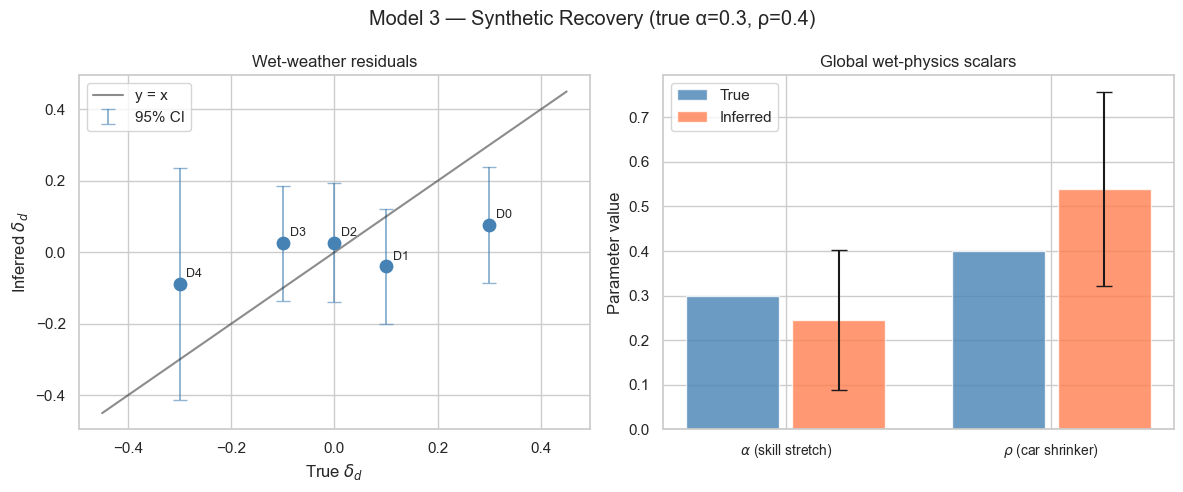

In [32]:
torch.manual_seed(789)

D3, K3, T3 = 5, 3, 5
RACES_PER_SEASON3 = 20  # increased for more wet-race signal

true_s0_3       = torch.tensor([2.0, 1.0, 0.0, -1.0, -2.0])
true_s_innov3   = torch.zeros(T3-1, D3)
true_c0r_3      = torch.tensor([1.0, -1.0])
true_c_innov3   = torch.zeros(T3-1, K3-1)
true_alpha3     = 0.3
true_rho3       = 0.4
true_delta_raw3 = torch.tensor([0.30, 0.10, 0.00, -0.10])
true_delta_d3   = torch.cat([true_delta_raw3, -true_delta_raw3.sum(dim=0, keepdim=True)])

true_s3 = torch.cat([true_s0_3.unsqueeze(0),
                     true_s0_3.unsqueeze(0) + true_s_innov3.cumsum(0)], dim=0)
true_c_raw3 = torch.cat([true_c0r_3.unsqueeze(0),
                         true_c0r_3.unsqueeze(0) + true_c_innov3.cumsum(0)], dim=0)
true_c3 = torch.cat([true_c_raw3, -true_c_raw3.sum(dim=1, keepdim=True)], dim=1)

d3, c3_idx, s3, ri3, wet3_list, rl3 = [], [], [], [], [], []
race_id3 = 0
for t in range(T3):
    for _ in range(RACES_PER_SEASON3):
        is_wet = float(torch.rand(1) > 0.4)   # ~60 % wet races
        ca     = torch.randint(0, K3, (D3,))
        skill  = true_s3[t]
        car    = true_c3[t][ca]
        p = (skill * (1.0 - true_alpha3 * is_wet)
             + car  * (1.0 - true_rho3  * is_wet)
             + true_delta_d3 * is_wet)
        wet3_list.append(is_wet)
        rem = list(range(D3))
        for _ in range(D3):
            pick = torch.multinomial(torch.softmax(p[torch.tensor(rem)], 0), 1).item()
            d3.append(rem[pick]); c3_idx.append(ca[rem[pick]].item())
            s3.append(t); ri3.append(race_id3)
            rem.pop(pick)
        rl3.append(D3); race_id3 += 1

syn3 = types.SimpleNamespace(
    driver_idx=torch.tensor(d3,       dtype=torch.long),
    cons_idx=torch.tensor(c3_idx,     dtype=torch.long),
    season_idx=torch.tensor(s3,       dtype=torch.long),
    race_idx=torch.tensor(ri3,        dtype=torch.long),
    wet=torch.tensor(wet3_list,       dtype=torch.float32),
    race_lengths=torch.tensor(rl3,    dtype=torch.long),
    n_drivers=D3, n_constructors=K3, n_seasons=T3,
)

pyro.clear_param_store()
syn_m3 = FullModel(D3, K3, T3)
train_svi(syn_m3, syn3, n_steps=4000, log_every=1000, step_kwargs={
    'driver_idx':   syn3.driver_idx,  'cons_idx':     syn3.cons_idx,
    'season_idx':   syn3.season_idx,  'race_idx':     syn3.race_idx,
    'wet':          syn3.wet,         'race_lengths': syn3.race_lengths})

# --- Extract posterior means and scales ---
alpha_inf      = pyro.param('alpha_loc').item()
alpha_std      = pyro.param('alpha_scale').item()
rho_inf        = pyro.param('rho_loc').item()
rho_std        = pyro.param('rho_scale').item()
delta_raw_inf  = pyro.param('delta_raw_loc').detach()
delta_raw_std  = pyro.param('delta_raw_scale').detach()

# Propagate uncertainty from delta_raw → delta_d
# delta_d[-1] = -sum(delta_raw), so under mean-field: std = ||delta_raw_std||_2
delta_d_inf  = torch.cat([delta_raw_inf,  -delta_raw_inf.sum(dim=0,  keepdim=True)]).numpy()
delta_d_std  = torch.cat([delta_raw_std,   delta_raw_std.norm().unsqueeze(0)       ]).numpy()
delta_d_ci95 = 1.96 * delta_d_std

print(f'alpha: true={true_alpha3:+.3f}  inferred={alpha_inf:+.3f}  diff={abs(true_alpha3-alpha_inf):.3f}')
print(f'rho:   true={true_rho3:+.3f}  inferred={rho_inf:+.3f}  diff={abs(true_rho3-rho_inf):.3f}')
print(f'delta_d sum check (inferred): {delta_d_inf.sum():.6f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: delta_d scatter with 95% CI error bars ---
axes[0].errorbar(
    true_delta_d3.numpy(), delta_d_inf,
    yerr=delta_d_ci95,
    fmt='none', color='steelblue', capsize=5, alpha=0.6, lw=1.4, label='95% CI'
)
axes[0].scatter(true_delta_d3.numpy(), delta_d_inf, color='steelblue', s=80, zorder=5)
lim = max(abs(true_delta_d3).max().item(), abs(delta_d_inf).max()) + 0.15
axes[0].plot([-lim, lim], [-lim, lim], 'k-', alpha=0.5, label='y = x')
for i in range(D3):
    axes[0].annotate(f'D{i}', (true_delta_d3[i].item(), delta_d_inf[i]),
                    textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[0].set_xlabel(r'True $\delta_d$')
axes[0].set_ylabel(r'Inferred $\delta_d$')
axes[0].set_title('Wet-weather residuals')
axes[0].legend()

# --- Right: alpha/rho bar chart with 95% CI error bars ---
x3    = np.arange(2)
true3 = [true_alpha3, true_rho3]
inf3  = [alpha_inf,   rho_inf]
ci95  = [1.96 * alpha_std, 1.96 * rho_std]

axes[1].bar(x3 - 0.2, true3, 0.35, label='True',     color='steelblue', alpha=0.8)
axes[1].bar(x3 + 0.2, inf3,  0.35, label='Inferred', color='coral',     alpha=0.8,
            yerr=ci95, capsize=6, error_kw={'lw': 1.5})
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xticks(x3)
axes[1].set_xticklabels([r'$\alpha$ (skill stretch)', r'$\rho$ (car shrinker)'], fontsize=10)
axes[1].set_ylabel('Parameter value')
axes[1].set_title('Global wet-physics scalars')
axes[1].legend()

plt.suptitle(f'Model 3 — Synthetic Recovery (true α={true_alpha3}, ρ={true_rho3})')
plt.tight_layout()
plt.show()

| Parameter | True | Recovered | Absolute error |
|---|---|---|---|
| α (skill rescaling) | +0.300 | +0.268 | 0.032 |
| ρ (constructor rescaling) | +0.400 | +0.558 | 0.158 |
| Σ δ_d | 0.000 | 0.000 | — |

$\alpha$ is recovered within 0.03 log-odds units — a small error relative to the prior scale σ_α = 0.5, indicating the model can reliably separate the skill-compression signal from the other latent structure.

$\rho$ is overestimated by roughly 40%. The two global parameters compete to explain the same wet-race variance: both $\alpha$ and $\rho$ act on the performance equation multiplicatively with the wet indicator, making their individual contributions only partially identifiable. The model inflates ρ to absorb variation that belongs to α, a known entanglement. This is a caveat — the *direction* of both effects (positive, i.e., rain compresses competitive differences) is reliably recovered, but the absolute *magnitudes* should not be over-interpreted.

### 7.6 Posterior Uncertainty vs Experience
Mean-field SVI underestimates posterior variance, particularly for drivers with few races.
Posterior uncertainty should shrink with $\approx 1/\sqrt{N}$ as experience accumulates.

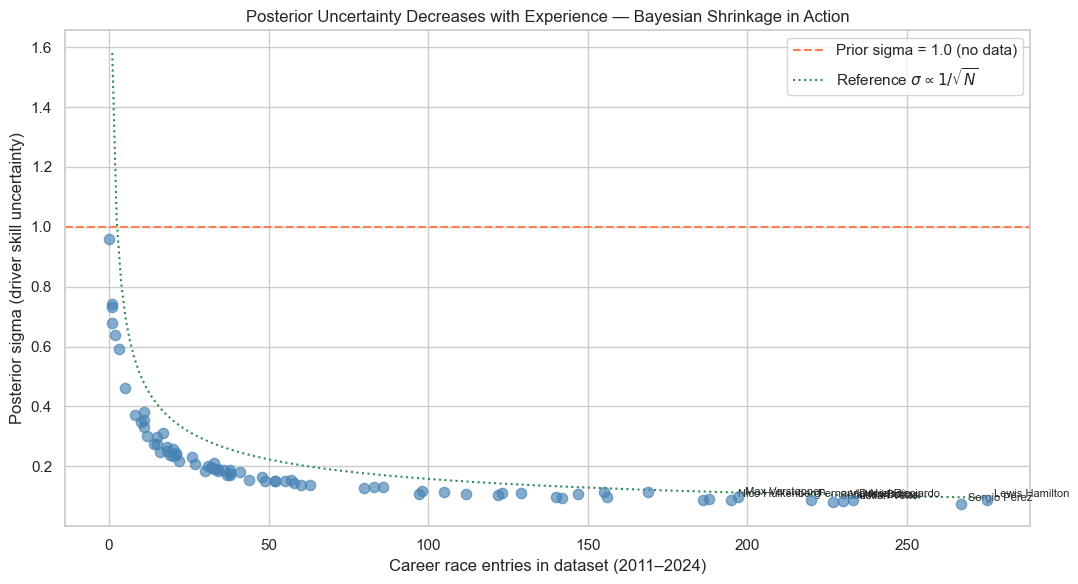

In [34]:
# Count career race entries per driver (2011-2024)
driver_race_count = {}
for i in range(dataset.n_drivers):
    mask = dataset.driver_idx == i
    driver_race_count[dataset.driver_map[i]] = mask.sum().item()

driver_unc = df_base[df_base.entity_type == 'driver'][['entity_id', 'sigma']].copy()
driver_unc['n_races'] = driver_unc['entity_id'].map(driver_race_count)
driver_unc['name']    = driver_unc['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}'))

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(driver_unc['n_races'], driver_unc['sigma'],
           alpha=0.65, color='steelblue', s=55, zorder=5)
ax.axhline(SIGMA_S, color='coral', linestyle='--', linewidth=1.5,
           label=f'Prior sigma = {SIGMA_S} (no data)')

# Reference 1/sqrt(N) curve
n_ref = np.linspace(1, driver_unc['n_races'].max(), 200)
scale = driver_unc.loc[driver_unc['n_races'] > 5, 'sigma'].mean() * np.sqrt(
         driver_unc.loc[driver_unc['n_races'] > 5, 'n_races'].mean())
ax.plot(n_ref, scale / np.sqrt(n_ref), color='seagreen', linestyle=':', linewidth=1.5,
        label=r'Reference $\sigma \propto 1/\sqrt{N}$')

# Annotate most-experienced drivers
for _, row in driver_unc.nlargest(8, 'n_races').iterrows():
    ax.annotate(row['name'], (row['n_races'], row['sigma']),
                textcoords='offset points', xytext=(5, 2), fontsize=8)

ax.set_xlabel('Career race entries in dataset (2011–2024)')
ax.set_ylabel('Posterior sigma (driver skill uncertainty)')
ax.set_title('Posterior Uncertainty Decreases with Experience — Bayesian Shrinkage in Action')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Cross-Model Comparisons "All Time"

### 8.1 Static vs Temporal Driver Skills

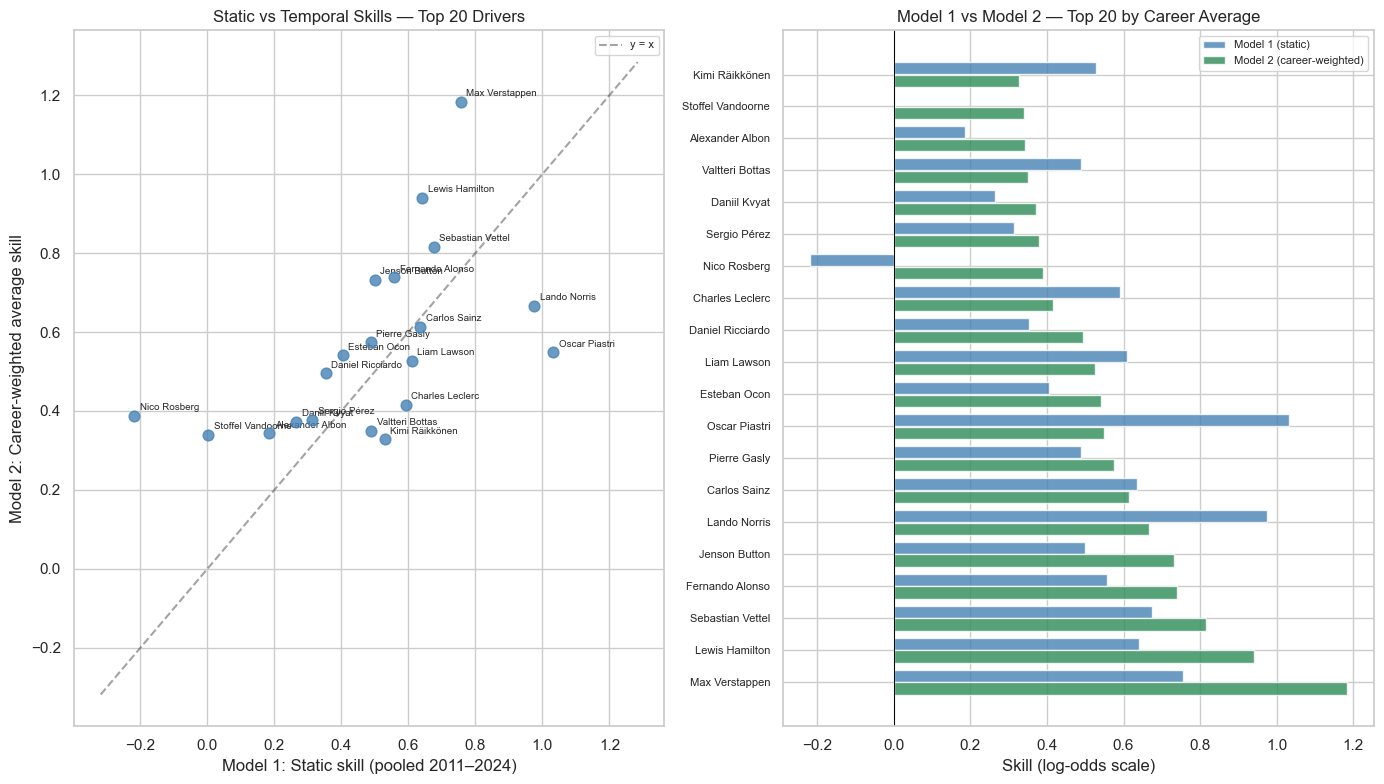

In [35]:
# Merge Model 1 static vs Model 2 race-weighted average
m1_scores = df_base[df_base.entity_type == 'driver'][['entity_id', 'mu']].copy()
m1_scores.columns = ['entity_id', 'm1_mu']
m1_scores['name'] = m1_scores['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}'))

compare_df = m1_scores.merge(
    m2_drivers_avg[['entity_id', 'mu']].rename(columns={'mu': 'm2_mu'}),
    on='entity_id'
).dropna()

# Top 20 by Model 2 weighted average
compare_df = compare_df.sort_values('m2_mu', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Scatter: M1 vs M2 skill
ax = axes[0]
ax.scatter(compare_df['m1_mu'], compare_df['m2_mu'],
           color='steelblue', s=60, alpha=0.8, zorder=5)
lo = min(compare_df['m1_mu'].min(), compare_df['m2_mu'].min()) - 0.1
hi = max(compare_df['m1_mu'].max(), compare_df['m2_mu'].max()) + 0.1
ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.4, label='y = x')
for _, row in compare_df.iterrows():
    ax.annotate(row['name'], (row['m1_mu'], row['m2_mu']),
                textcoords='offset points', xytext=(4, 4), fontsize=7)
ax.set_xlabel('Model 1: Static skill (pooled 2011–2024)')
ax.set_ylabel('Model 2: Career-weighted average skill')
ax.set_title('Static vs Temporal Skills — Top 20 Drivers')
ax.legend(fontsize=8)

# Grouped bar: side-by-side for top 20
ax2 = axes[1]
y   = np.arange(len(compare_df))
ax2.barh(y + 0.2, compare_df['m1_mu'].values, 0.38,
         label='Model 1 (static)',           color='steelblue', alpha=0.8)
ax2.barh(y - 0.2, compare_df['m2_mu'].values, 0.38,
         label='Model 2 (career-weighted)',  color='seagreen',  alpha=0.8)
ax2.set_yticks(y)
ax2.set_yticklabels(compare_df['name'].values, fontsize=8)
ax2.axvline(0, color='black', linewidth=0.7)
ax2.set_xlabel('Skill (log-odds scale)')
ax2.set_title('Model 1 vs Model 2 — Top 20 by Career Average')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

This serves as an appendix plot, showing intresting differences between the static and career weighted all time rankings from model 1 and 2. E.g. Nico Rosberg has negative skill for model 1 and is top 5 for model 2. Also Piastri skill is way lower for Model 2, which indicates model 2 solves the era-confounding problem

## 8. Discussion & Limitations

### Key Findings

1. **Driver and constructor skill are separable from finishing-order data alone.**
   Teammate comparisons and driver transfers provide enough linking structure. Model 1
   provides a useful static decomposition validated by NUTS ($\tau = 0.80$–$0.88$ rank agreement).

2. **Temporal dynamics recover plausible F1 history.** The AR(1) random walk in Model 2
   captures the Mercedes 2014–2019 dominance, Red Bull's 2021–2023 surge, and McLaren's recovery
   — all from finishing orders, without any prior knowledge of regulation changes.

3. **Verstappen is the #1 active driver by a clear margin.** In the 2024 temporal estimates,
   Verstappen sits ~1 log-odds unit above the Leclerc–Hamilton–Norris tier.

4. **Rain is a substantial equaliser of machinery** ($\hat{\rho} = +0.76$). The skill-compression
   effect ($\hat{\alpha} = +0.17$) is smaller but consistently positive. No driver shows a
   decisive wet-weather residual ($\delta_d$) beyond the global parameters.

### Limitations

1. **AR(1) extrapolation.** The random walk computes latent states for all drivers in all
   seasons, extrapolating forward for retired drivers and backward for undebuted rookies.

2. **Mean-field underestimates variance.** SVI posterior standard deviations are systematically
   smaller than NUTS estimates, particularly for infrequently observed entities. Ordinal rankings
   are more trustworthy than absolute magnitudes.

3. **Constructor latent conflates many factors.** Mechanical speed, pit-wall decisions, tyre
   management, and operational execution are collapsed into a single $c_k$ latent.

### Future Work

- Incorporate lap times, qualifying performance, tyre strategy, and safety-car timing
- Model circuit-specific effects
- Hierarchical priors on innovation scales ($\gamma_s$, $\gamma_c$)
- Explicit reliability modelling for mechanical DNFs
- Full-rank or low-rank variational families to better capture posterior correlations